# Análise Long Neck — NENO (Refatorada)

## Estrutura
1. **Base de dados** — leitura e cálculos fiéis ao Excel original
2. **Alavancas operacionais** — implementadas uma a uma
3. **Análise final** — visualizações e respostas ao case

## Etapa 1 — Base de Dados

In [121]:
import pandas as pd
import numpy as np

ARQUIVO = "Analise_LongNeck_WSNP - Rafael.xlsb"

# Araguaia excluida: revendedores autonomos que retiram em Uberlandia e
# gerem o proprio estoque — DOI minimo nao e responsabilidade do NENO.
REGIOES_NENO = ["Mapapi", "NE Norte", "NE Sul", "NO Centro"]

MAPA_SEMANAS = {
    0: "W0 - 02/02", 1: "W1 - 09/02", 2: "W2 - 16/02", 3: "W3 - 23/02",
    4: "W4 - 02/03", 5: "W5 - 09/03", 6: "W6 - 16/03", 7: "W7 - 23/03",
}

SKU_MALZBIER  = "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4"
SKU_GOOSE     = "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12"
SKU_PATAGONIA = "PATAGONIA AMBER LAGER LN355ML CX12"
SKU_COLORADO  = "COLORADO LAGER LN 355ML CX C/12"

FATOR_FEV_MALZBIER_NOVA = 1.30  # +30% Malzbier em fevereiro no cenário nova
FATOR_MAR_NOVA          = 1.10  # +10% todos os SKUs em março no cenário nova
BIAS                    = 0.09  # ±9% aditivo sobre o fator de demanda

In [122]:
# ==============================================================
# Posições das colunas por semana
# ==============================================================
# NENO: W0 tem EI Semana; W1-W3 não (EI calculado em cadeia)
_NENO_COLS = {
    0: dict(demanda=1,  wsnp=3,  ei=5,  ti=7,  tc=8,  tr=9,  transito=10),
    1: dict(demanda=14, wsnp=16,        ti=18, tc=19, tr=20, transito=21),
    2: dict(demanda=25, wsnp=27,        ti=29, tc=30, tr=31, transito=32),
    3: dict(demanda=36, wsnp=38,        ti=40, tc=41, tr=42, transito=43),
}
# Nota: colunas corretas para o arquivo Analise_LongNeck_WSNP_-_Rafael.xlsb
# Diferem do arquivo original (original.xlsb tem deslocamento +2 no inicio)

# SP: mesma estrutura NENO deslocada +1 coluna (SKO na posição 0)
_SP_COLS = {
    0: dict(demanda=2,  wsnp=4,  ei=6,  ti=8,  tc=9,  tr=10, transito=11),
    1: dict(demanda=15, wsnp=17,        ti=19, tc=20, tr=21, transito=22),
    2: dict(demanda=26, wsnp=28,        ti=30, tc=31, tr=32, transito=33),
    3: dict(demanda=37, wsnp=39,        ti=41, tc=42, tr=43, transito=44),
}


def parse_neno(arquivo, sheet_name, sku, cenario):
    """Lê aba NENO e retorna DataFrame longo de fevereiro (W0-W3)."""
    raw   = pd.read_excel(arquivo, sheet_name=sheet_name, header=None, engine="pyxlsb")
    dados = raw.iloc[1:].copy()
    dados = dados[dados[0].isin(REGIOES_NENO)].reset_index(drop=True)

    blocos = []
    for w, c in _NENO_COLS.items():
        bloco = pd.DataFrame({
            "geo_reg":         dados[0].values,
            "demanda":         pd.to_numeric(dados[c["demanda"]], errors="coerce").values,
            "wsnp":            pd.to_numeric(dados[c["wsnp"]],    errors="coerce").fillna(0).values,
            "ei_semana":       pd.to_numeric(dados[c["ei"]],      errors="coerce").values if "ei" in c else np.nan,
            "transf_interna":  pd.to_numeric(dados[c["ti"]],      errors="coerce").fillna(0).values,
            "transf_ext_cabo": pd.to_numeric(dados[c["tc"]],      errors="coerce").fillna(0).values,
            "transf_ext_rodo": pd.to_numeric(dados[c["tr"]],      errors="coerce").fillna(0).values,
            "transito":        pd.to_numeric(dados[c["transito"]], errors="coerce").fillna(0).values,
            "semana_idx":      w,
        })
        blocos.append(bloco)

    df = pd.concat(blocos, ignore_index=True)
    df["sku"]       = sku
    df["cenario"]   = cenario
    df["ef_semana"] = np.nan
    df["suf_ini_d"] = np.nan
    df["suf_f_d"]   = np.nan
    return df


def parse_sp(arquivo):
    """Lê aba SãoPaulo e retorna DataFrame longo de fevereiro (W0-W3)."""
    raw   = pd.read_excel(arquivo, sheet_name="SãoPaulo", header=None, engine="pyxlsb")
    dados = raw.iloc[1:].dropna(subset=[0]).reset_index(drop=True)

    blocos = []
    for w, c in _SP_COLS.items():
        bloco = pd.DataFrame({
            "sku":             dados[0].values,
            "geo_reg":         "SP",
            "demanda":         pd.to_numeric(dados[c["demanda"]], errors="coerce").values,
            "wsnp":            pd.to_numeric(dados[c["wsnp"]],    errors="coerce").fillna(0).values,
            "ei_semana":       pd.to_numeric(dados[c["ei"]],      errors="coerce").values if "ei" in c else np.nan,
            "transf_interna":  pd.to_numeric(dados[c["ti"]],      errors="coerce").fillna(0).values,
            "transf_ext_cabo": pd.to_numeric(dados[c["tc"]],      errors="coerce").fillna(0).values,
            "transf_ext_rodo": pd.to_numeric(dados[c["tr"]],      errors="coerce").fillna(0).values,
            "transito":        pd.to_numeric(dados[c["transito"]], errors="coerce").fillna(0).values,
            "semana_idx":      w,
        })
        blocos.append(bloco)

    df = pd.concat(blocos, ignore_index=True)
    df["cenario"]   = "atual"
    df["ef_semana"] = np.nan
    df["suf_ini_d"] = np.nan
    df["suf_f_d"]   = np.nan
    return df


def adiciona_marco(fev_df, fator_demanda):
    """
    Adiciona 4 semanas de março (W4-W7) ao DataFrame de fevereiro.

    - Demanda:  demanda_fev * fator_demanda
    - WSNP:     replica de fevereiro (W4=W0, W5=W1, W6=W2, W7=W3)
    - Transito: TRANSF_EXT_CABO decidido 3 semanas antes
                (W4=W1_cabo, W5=W2_cabo, W6=W3_cabo, W7=0)
    - Demais:   zero — serão preenchidos pelas alavancas
    """
    linhas = []
    for keys, grp in fev_df.groupby(["sku", "cenario", "geo_reg"]):
        grp = grp.sort_values("semana_idx").reset_index(drop=True)
        for i in range(4):
            fev_row  = grp.iloc[i]
            cabo_idx = i + 1   # W4->W1, W5->W2, W6->W3, W7->inexistente(0)
            transito = float(grp.iloc[cabo_idx]["transf_ext_cabo"]) if cabo_idx < 4 else 0.0
            linhas.append({
                "sku":             keys[0],
                "cenario":         keys[1],
                "geo_reg":         keys[2],
                "semana_idx":      i + 4,
                "demanda":         float(fev_row["demanda"]) * fator_demanda,
                "wsnp":            float(fev_row["wsnp"]),
                "ei_semana":       np.nan,
                "transf_interna":  0.0,
                "transf_ext_cabo": 0.0,
                "transf_ext_rodo": 0.0,
                "transito":        transito,
                "ef_semana":       np.nan,
                "suf_ini_d":       np.nan,
                "suf_f_d":         np.nan,
            })
    return pd.concat([fev_df, pd.DataFrame(linhas)], ignore_index=True)


def calcula_metricas(df):
    """
    Calcula em cadeia para cada (sku, cenario, geo_reg):
      EI_t      = EF_(t-1)              [t>0; t=0 vem do Excel]
      EF        = EI + WSNP + transf_interna + transf_ext_cabo + transf_ext_rodo + transito - demanda
      suf_ini_d = EI / (demanda / 6)
      suf_f_d   = EF / (demanda_(t+1) / 6)  [ultima semana usa propria demanda]
    """
    df = df.sort_values(["sku", "cenario", "geo_reg", "semana_idx"]).copy()

    for _, grp in df.groupby(["sku", "cenario", "geo_reg"]):
        idx = grp.index.tolist()
        n   = len(idx)

        for i, ri in enumerate(idx):
            if i > 0:
                df.loc[ri, "ei_semana"] = df.loc[idx[i - 1], "ef_semana"]

            ei  = df.loc[ri, "ei_semana"]
            dem = df.loc[ri, "demanda"]

            df.loc[ri, "suf_ini_d"] = (
                ei / (dem / 6) if pd.notna(dem) and dem != 0 else np.nan
            )

            ef = (
                ei
                + df.loc[ri, "wsnp"]
                + df.loc[ri, "transf_interna"]
                + min(float(df.loc[ri, "transf_ext_cabo"]), 0)
                + df.loc[ri, "transf_ext_rodo"]
                + df.loc[ri, "transito"]
                - dem
            )
            df.loc[ri, "ef_semana"] = ef

            dem_ref = df.loc[idx[i + 1], "demanda"] if i < n - 1 else dem
            df.loc[ri, "suf_f_d"] = (
                ef / (dem_ref / 6) if pd.notna(dem_ref) and dem_ref != 0 else np.nan
            )

    df["semana"] = df["semana_idx"].map(MAPA_SEMANAS)

    cols = [
        "sku", "cenario", "geo_reg", "semana_idx", "semana",
        "demanda", "wsnp", "ei_semana", "suf_ini_d",
        "transf_interna", "transf_ext_cabo", "transf_ext_rodo", "transito",
        "ef_semana", "suf_f_d",
    ]
    return df[cols].reset_index(drop=True)


In [123]:
# Custo de transferência (cabotagem SP -> NENO)
custo_transf = pd.read_excel(ARQUIVO, sheet_name="custo_transf", engine="pyxlsb")
custo_transf.columns = custo_transf.columns.str.strip()
custo_transf = custo_transf.rename(columns={
    "SKU": "sku", "Origem": "origem", "Destino": "destino", "Reais / HL": "custo_cabo_hl"
})
custo_transf["custo_rodo_hl"]          = custo_transf["custo_cabo_hl"] * 1.60
custo_transf["custo_rodo_esperado_hl"] = custo_transf["custo_rodo_hl"] * 1.05  # +5% avaria
custo_transf = custo_transf.dropna(subset=["sku"]).reset_index(drop=True)

# Custo de produção em SP
_raw_prod = pd.read_excel(ARQUIVO, sheet_name="custo_prod", header=None, engine="pyxlsb")
custo_prod = _raw_prod.iloc[1:, [0, 3]].copy()
custo_prod.columns = ["sku", "custo_prod_hl"]
custo_prod = custo_prod.dropna(subset=["sku"]).reset_index(drop=True)

# MACO — margem quando a produção é no NENO
_raw_maco = pd.read_excel(ARQUIVO, sheet_name="maco", header=None, engine="pyxlsb")
maco = _raw_maco.iloc[1:, [0, 3]].copy()
maco.columns = ["sku", "maco_hl"]
maco = maco.dropna(subset=["sku"]).reset_index(drop=True)

print("custo_transf:"); display(custo_transf)
print("\ncusto_prod:");  display(custo_prod)
print("\nmaco:");        display(maco)


custo_transf:


,sku,origem,destino,custo_cabo_hl,custo_rodo_hl,custo_rodo_esperado_hl
0,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,76.592891,122.548625,128.676056
1,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,82.079980,131.327968,137.894366
2,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,82.395382,131.832612,138.424242
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,84.579425,135.327080,142.093434
4,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,88.298160,141.277056,148.340909
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,95.328283,152.525253,160.151515



custo_prod:


,sku,custo_prod_hl
0,COLORADO LAGER LN 355ML CX C/12,150
1,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,155
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,149



maco:


,sku,maco_hl
0,COLORADO LAGER LN 355ML CX C/12,300
1,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,350
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,285


In [124]:
# --- Leitura de fevereiro ---------------------------------------------------
malzbier_atual_fev = parse_neno(ARQUIVO, "Malzbier",      SKU_MALZBIER,  "atual")  # demanda base
malzbier_nova_fev  = parse_neno(ARQUIVO, "Malzbier_Nova", SKU_MALZBIER,  "nova")   # demanda +30% fev
goose_fev          = parse_neno(ARQUIVO, "Goose",         SKU_GOOSE,     "atual")
patagonia_fev      = parse_neno(ARQUIVO, "Patagonia",     SKU_PATAGONIA, "atual")
colorado_fev       = parse_neno(ARQUIVO, "Colorado",      SKU_COLORADO,  "atual")

# Goose/Patagonia/Colorado: mesma demanda em fev nos cenários base e bias
goose_nova_fev     = goose_fev.copy();     goose_nova_fev["cenario"]     = "nova"
patagonia_nova_fev = patagonia_fev.copy(); patagonia_nova_fev["cenario"] = "nova"
colorado_nova_fev  = colorado_fev.copy();  colorado_nova_fev["cenario"]  = "nova"

# --- Cenários bias ----------------------------------------------------------
# Bias é ADITIVO sobre o fator de demanda:
#   Malzbier fev: base × (1.30 ± 0.09)
#   Todos    mar: fev  × (1.10 ± 0.09)   ← inclusive Malzbier

def fev_com_fator(fev_atual_df, cenario, fator):
    df = fev_atual_df.copy()
    df["demanda"] = df["demanda"] * fator
    df["cenario"] = cenario
    return df

# Malzbier: bias em fev
malzbier_nova_bp_fev = fev_com_fator(malzbier_atual_fev, "nova_bias_pos", FATOR_FEV_MALZBIER_NOVA + BIAS)  # ×1.39
malzbier_nova_bn_fev = fev_com_fator(malzbier_atual_fev, "nova_bias_neg", FATOR_FEV_MALZBIER_NOVA - BIAS)  # ×1.21

# Outros: fev inalterado
goose_nova_bp_fev     = goose_nova_fev.copy();     goose_nova_bp_fev["cenario"]     = "nova_bias_pos"
patagonia_nova_bp_fev = patagonia_nova_fev.copy(); patagonia_nova_bp_fev["cenario"] = "nova_bias_pos"
colorado_nova_bp_fev  = colorado_nova_fev.copy();  colorado_nova_bp_fev["cenario"]  = "nova_bias_pos"

goose_nova_bn_fev     = goose_nova_fev.copy();     goose_nova_bn_fev["cenario"]     = "nova_bias_neg"
patagonia_nova_bn_fev = patagonia_nova_fev.copy(); patagonia_nova_bn_fev["cenario"] = "nova_bias_neg"
colorado_nova_bn_fev  = colorado_nova_fev.copy();  colorado_nova_bn_fev["cenario"]  = "nova_bias_neg"

# --- Adiciona março ---------------------------------------------------------
# Todos os SKUs usam o mesmo fator em março para cada cenário
_neno_atual_raw = pd.concat(
    [malzbier_atual_fev, goose_fev, patagonia_fev, colorado_fev], ignore_index=True
)
_neno_nova_raw = pd.concat(
    [malzbier_nova_fev, goose_nova_fev, patagonia_nova_fev, colorado_nova_fev], ignore_index=True
)
_neno_nova_bp_raw = pd.concat(
    [malzbier_nova_bp_fev, goose_nova_bp_fev, patagonia_nova_bp_fev, colorado_nova_bp_fev], ignore_index=True
)
_neno_nova_bn_raw = pd.concat(
    [malzbier_nova_bn_fev, goose_nova_bn_fev, patagonia_nova_bn_fev, colorado_nova_bn_fev], ignore_index=True
)

# --- Calcula métricas -------------------------------------------------------
neno_atual   = calcula_metricas(adiciona_marco(_neno_atual_raw,   fator_demanda=1.0))
neno_nova    = calcula_metricas(adiciona_marco(_neno_nova_raw,    fator_demanda=FATOR_MAR_NOVA))
neno_nova_bp = calcula_metricas(adiciona_marco(_neno_nova_bp_raw, fator_demanda=FATOR_MAR_NOVA + BIAS))
neno_nova_bn = calcula_metricas(adiciona_marco(_neno_nova_bn_raw, fator_demanda=FATOR_MAR_NOVA - BIAS))

# --- Bases individuais (conveniência) ---------------------------------------
malzbier_atual = neno_atual[neno_atual["sku"] == SKU_MALZBIER].reset_index(drop=True)
malzbier_nova  = neno_nova[neno_nova["sku"]   == SKU_MALZBIER].reset_index(drop=True)
goose          = neno_atual[neno_atual["sku"]  == SKU_GOOSE].reset_index(drop=True)
patagonia      = neno_atual[neno_atual["sku"]  == SKU_PATAGONIA].reset_index(drop=True)
colorado       = neno_atual[neno_atual["sku"]  == SKU_COLORADO].reset_index(drop=True)

print(f"neno_atual:   {neno_atual.shape}")
print(f"neno_nova:    {neno_nova.shape}")
print(f"neno_nova_bp: {neno_nova_bp.shape}  (Malzbier fev ×1.39 | todos mar ×1.19)")
print(f"neno_nova_bn: {neno_nova_bn.shape}  (Malzbier fev ×1.21 | todos mar ×1.01)")

neno_atual:   (128, 15)
neno_nova:    (128, 15)
neno_nova_bp: (128, 15)  (Malzbier fev ×1.39 | todos mar ×1.19)
neno_nova_bn: (128, 15)  (Malzbier fev ×1.21 | todos mar ×1.01)


In [125]:
sp_fev = parse_sp(ARQUIVO)

# Estende SP para março: mesma demanda e WSNP de fevereiro, transito propagado
sp = calcula_metricas(adiciona_marco(sp_fev, fator_demanda=1.0))

print(f"sp: {sp.shape}")

sp: (24, 15)


## Etapa 2 — Alavancas Operacionais

### Alavanca 1 — Redistribuição Interna (Transferência Interna)

In [126]:
import numpy as np

# ── Constantes de capacidade extra (PCP sugestao + folga) ─────────────
_EXTRA_CEARA = {0: 360, 1: 1800, 2: 0, 3: 0}  # folga CE por semana
_EXTRA_PE    = {0: 0,   1: 7200, 2: 0, 3: 0}  # folga PE por semana

# ── Alteracoes de PCP (ultimo recurso, para fechar gaps residuais) ────────
# Fix 1: PE Colorado W2/W6 reduzido em 500 HL → libera PE para Malzbier→Patagonia
# Fix 2: PE Malzbier W3/W7 acrescido de 3000 HL → substitui BudZero no PE
# Impacto: elimina gap de Patagonia W6 (11.7d) e Malzbier NO Centro W3 (5.0d)
_PE_COLO_OVERRIDE  = {2: -500}   # reducao PE Colorado nas semanas wfev=2
_PE_MALZ_BONUS     = {3: 3000}   # adicional PE Malzbier nas semanas wfev=3

# ── Mapeamento SP -> NENO ────────────────────────────────────────
REGIOES_A3 = REGIOES_NENO  # Araguaia excluida (autogestao)
GEO_DESTINO = {
    "NE Sul":    "BR04 - F. CAMACARI - PLANT - BA",
    "Mapapi":    "BR06 - F. FONTE MATA - RDC - PB",
    "NE Norte":  "BR06 - F. FONTE MATA - RDC - PB",
    "NO Centro": "BR06 - F. FONTE MATA - RDC - PB",
}


def _aplica_a1_semana(df, mask_sc, geos, ridxs, ei, wsnp, cabo, rodo, transito, dem, dem_ref):
    """Redistribuicao interna para uma semana. Retorna delta (array)."""
    ef        = ei + wsnp + np.minimum(cabo, 0) + rodo + transito - dem
    suf_fd    = np.where(dem_ref != 0, ef / (dem_ref / 6), np.nan)
    target_ef = dem_ref / 6 * 12
    delta     = np.zeros(len(ridxs))

    if np.nanmax(suf_fd) >= 12:
        surplus          = np.maximum(0.0, ef - target_ef)
        deficit          = np.maximum(0.0, target_ef - ef)
        surplus_restante = surplus.copy()
        for i in np.argsort(deficit):
            if deficit[i] < 1e-6:
                continue
            total_s = surplus_restante.sum()
            if total_s < 1e-6:
                break
            transfer = min(deficit[i], total_s)
            delta[i] += transfer
            for j in range(len(ridxs)):
                if surplus_restante[j] > 1e-6:
                    give                = transfer * surplus_restante[j] / total_s
                    delta[j]           -= give
                    surplus_restante[j] -= give
    else:
        surplus = np.maximum(0.0, ef - target_ef)
        deficit = np.maximum(0.0, target_ef - ef)
        total_s = surplus.sum()
        total_d = deficit.sum()
        if total_s > 1e-6 and total_d > 1e-6:
            for i in range(len(ridxs)):
                if surplus[i] > 1e-6:
                    delta[i] = -min(surplus[i], surplus[i] / total_s * min(total_s, total_d))
                elif deficit[i] > 1e-6:
                    delta[i] = min(deficit[i], deficit[i] / total_d * min(total_s, total_d))
    return delta


def roda(base_df, alavancas, sp_df=None, custo_transf=None, custo_prod=None):
    """
    Aplica lista de alavancas semana a semana sobre base_df.

    alavancas: lista com subset de [1, 2, 3, 4]
    Retorna (df_resultado, custos) onde custos = {cenario: total}
    """
    df = base_df.copy()
    df["transf_interna"]  = 0.0
    df["transf_ext_rodo"] = df["transf_ext_rodo"].copy()  # mantem original
    df["transito"]        = df["transito"].copy()          # mantem transito original (cabo ja decidido)
    df["wsnp"]            = df["wsnp"].copy()

    semanas  = sorted(df["semana_idx"].unique())
    cenarios = df["cenario"].unique()
    skus     = df["sku"].unique()

    # Custos acumulados por cenario
    custos = {cen: 0.0 for cen in cenarios}

    # Lookup de custos
    ct = {}
    cp = {}
    if custo_transf is not None:
        ct = (custo_transf
              .set_index(["sku", "destino"])[["custo_cabo_hl", "custo_rodo_esperado_hl"]]
              .to_dict("index"))
    if custo_prod is not None:
        cp = custo_prod.set_index("sku")["custo_prod_hl"].to_dict()

    # EI corrente: {(sku, cenario, geo_reg): valor}
    ei_cur = {}
    for _, row in df[df["semana_idx"] == semanas[0]].iterrows():
        ei_cur[(row["sku"], row["cenario"], row["geo_reg"])] = float(row["ei_semana"])

    # EF corrente de SP por (sku, semana): usado por A3
    sp_ef = {}
    if sp_df is not None and 3 in alavancas:
        for _, row in sp_df.iterrows():
            sp_ef[(row["sku"], int(row["semana_idx"]))] = float(row["ef_semana"])

    for w in semanas:
        mask_w  = df["semana_idx"] == w
        w_fev   = w % 4
        is_last = (w == semanas[-1])

        # Atualiza EI no df com o EI corrente propagado
        for ridx, row in df[mask_w].iterrows():
            key = (row["sku"], row["cenario"], row["geo_reg"])
            df.loc[ridx, "ei_semana"] = ei_cur.get(key, float(row["ei_semana"]))

        # dem_ref: demanda da proxima semana (para calculo de DOI)
        dem_next = {}
        if not is_last:
            for _, row in df[df["semana_idx"] == w + 1].iterrows():
                dem_next[(row["sku"], row["cenario"], row["geo_reg"])] = float(row["demanda"])

        # EF corrente desta semana (antes de qualquer alavanca)
        ef_cur = {}
        for ridx, row in df[mask_w].iterrows():
            key = (row["sku"], row["cenario"], row["geo_reg"])
            ei  = ei_cur.get(key, float(row["ei_semana"]))
            ef  = (ei + float(row["wsnp"]) + float(row["transf_interna"])
                   + min(float(row["transf_ext_cabo"]), 0) + float(row["transf_ext_rodo"])
                   + float(row["transito"]) - float(row["demanda"]))
            ef_cur[key] = ef

        # ── ALAVANCA 1 ───────────────────────────────────────────
        if 1 in alavancas:
            for (sku, cenario) in [(r["sku"], r["cenario"]) for _, r in df[mask_w].drop_duplicates(["sku","cenario"]).iterrows()]:
                mask_sc_w = mask_w & (df["sku"] == sku) & (df["cenario"] == cenario)
                rows   = df[mask_sc_w]
                geos   = rows["geo_reg"].values
                ridxs  = rows.index.tolist()

                ei       = np.array([ei_cur.get((sku, cenario, g), 0.0) for g in geos], dtype=float)
                wsnp     = rows["wsnp"].values.astype(float)
                cabo     = rows["transf_ext_cabo"].values.astype(float)
                rodo     = rows["transf_ext_rodo"].values.astype(float)
                transito = rows["transito"].values.astype(float)
                dem      = rows["demanda"].values.astype(float)
                dem_ref  = np.array(
                    [dem_next.get((sku, cenario, g), d) for g, d in zip(geos, dem)], dtype=float
                )

                delta = _aplica_a1_semana(df, mask_sc_w, geos, ridxs, ei, wsnp, cabo, rodo, transito, dem, dem_ref)

                for i, ridx in enumerate(ridxs):
                    df.loc[ridx, "transf_interna"] = delta[i]
                    ef_cur[(sku, cenario, geos[i])] = ei[i] + wsnp[i] + delta[i] + min(cabo[i], 0) + rodo[i] + transito[i] - dem[i]

        # ── ALAVANCA 2 ───────────────────────────────────────────
        if 2 in alavancas:
            custo_hl_prod = custo_prod.set_index("sku")["custo_prod_hl"].to_dict() if custo_prod is not None else {}

            for cenario in cenarios:
                mask_cen_w = mask_w & (df["cenario"] == cenario)

                def add_wsnp_w(sku_alvo, extra_hl):
                    mask_sku = mask_cen_w & (df["sku"] == sku_alvo)
                    rows  = df[mask_sku]
                    if rows.empty:
                        return 0.0
                    geos  = rows["geo_reg"].values
                    ridxs = rows.index.tolist()
                    dem   = rows["demanda"].values.astype(float)
                    dem_ref = np.array(
                        [dem_next.get((sku_alvo, cenario, g), d) for g, d in zip(geos, dem)], dtype=float
                    )
                    ef      = np.array([ef_cur.get((sku_alvo, cenario, g), 0.0) for g in geos], dtype=float)
                    deficit = np.maximum(0.0, dem_ref / 6 * 12 - ef)

                    delta    = np.zeros(len(ridxs))
                    restante = float(extra_hl)
                    for i in np.argsort(deficit):
                        if restante < 1e-6:
                            break
                        fill      = min(deficit[i], restante)
                        delta[i] += fill
                        restante  -= fill
                    if restante > 1e-6 and dem.sum() > 0:
                        delta += restante * dem / dem.sum()

                    for i, ridx in enumerate(ridxs):
                        df.loc[ridx, "wsnp"] += delta[i]
                        ef_cur[(sku_alvo, cenario, geos[i])] += delta[i]
                    return delta.sum()

                extra_ceara = _EXTRA_CEARA[w_fev]
                if extra_ceara > 0:
                    hl = add_wsnp_w(SKU_PATAGONIA, extra_ceara)
                    custos[cenario] += hl * custo_hl_prod.get(SKU_PATAGONIA, 0)

                extra_pe = _EXTRA_PE[w_fev]
                if extra_pe > 0:
                    skus_validos = [s for s in skus if s != SKU_GOOSE]
                    deficit_sku  = {}
                    dem_tot_sku  = {}
                    for sku in skus_validos:
                        mask_sku = mask_cen_w & (df["sku"] == sku)
                        geos_sku = df[mask_sku]["geo_reg"].values
                        dem_sku  = df[mask_sku]["demanda"].values.astype(float)
                        ef_sku   = np.array([ef_cur.get((sku, cenario, g), 0.0) for g in geos_sku])
                        dem_ref_sku = np.array(
                            [dem_next.get((sku, cenario, g), d) for g, d in zip(geos_sku, dem_sku)], dtype=float
                        )
                        deficit_sku[sku]  = np.maximum(0.0, dem_ref_sku / 6 * 12 - ef_sku).sum()
                        dem_tot_sku[sku]  = dem_sku.sum()

                    total_def = sum(deficit_sku.values())
                    alocacao  = {sku: 0.0 for sku in skus_validos}
                    restante  = float(extra_pe)

                    if total_def > 1e-6:
                        for sku in skus_validos:
                            share = deficit_sku[sku] / total_def * restante
                            alocacao[sku] += min(share, deficit_sku[sku])
                        restante -= sum(alocacao.values())

                    if restante > 1e-6:
                        total_dem = sum(dem_tot_sku.values())
                        if total_dem > 0:
                            for sku in skus_validos:
                                alocacao[sku] += restante * dem_tot_sku[sku] / total_dem

                    for sku, hl in alocacao.items():
                        if hl > 1e-6:
                            used = add_wsnp_w(sku, hl)
                            custos[cenario] += used * custo_hl_prod.get(sku, 0)

        # ── ALAVANCA 3 ───────────────────────────────────────────
        if 3 in alavancas and sp_df is not None:
            for (sku, cenario) in [(r["sku"], r["cenario"]) for _, r in df[mask_w].drop_duplicates(["sku","cenario"]).iterrows()]:
                if sku == SKU_PATAGONIA:
                    continue
                mask_sc_w = mask_w & (df["sku"] == sku) & (df["cenario"] == cenario)

                deficit = {}
                for geo in REGIOES_A3:
                    mask_g = mask_sc_w & (df["geo_reg"] == geo)
                    if not mask_g.any():
                        continue
                    row = df[mask_g].iloc[0]
                    ef  = ef_cur.get((sku, cenario, geo), 0.0)
                    dr  = dem_next.get((sku, cenario, geo), float(row["demanda"]))
                    target = 12.0 * dr / 6.0 if dr > 0 else 0.0
                    deficit[geo] = max(0.0, target - ef)

                total_deficit = sum(deficit.values())
                if total_deficit <= 0:
                    continue

                # Cabo: pedido em w-3, chega em w
                if w >= 3:
                    w_order    = w - 3
                    avail_cabo = max(0.0, sp_ef.get((sku, w_order), 0.0)
                                    - 12.0 * float(sp_df[(sp_df["sku"]==sku) & (sp_df["semana_idx"]==w_order)]["demanda"].iloc[0]) / 6.0
                                    if not sp_df[(sp_df["sku"]==sku) & (sp_df["semana_idx"]==w_order)].empty else 0.0)

                    if avail_cabo > 0:
                        cabo_total = min(avail_cabo, total_deficit)
                        # Deduz de SP para todas as semanas >= w_order
                        for ww in semanas:
                            if ww >= w_order:
                                sp_ef[(sku, ww)] = sp_ef.get((sku, ww), 0.0) - cabo_total

                        for geo, def_hl in list(deficit.items()):
                            if def_hl <= 0:
                                continue
                            share = def_hl / total_deficit * cabo_total
                            mask_g = mask_sc_w & (df["geo_reg"] == geo)
                            df.loc[mask_g, "transito"] += share
                            ef_cur[(sku, cenario, geo)] += share
                            deficit[geo] -= share
                            destino = GEO_DESTINO.get(geo)
                            custos[cenario] += share * ct.get((sku, destino), {}).get("custo_cabo_hl", 0.0)

                        total_deficit = sum(deficit.values())

                # Rodo: pedido e chegada em w
                if total_deficit > 0:
                    sp_row = sp_df[(sp_df["sku"]==sku) & (sp_df["semana_idx"]==w)]
                    if not sp_row.empty:
                        sp_dem = float(sp_row["demanda"].iloc[0])
                        avail_rodo = max(0.0, sp_ef.get((sku, w), 0.0) - 12.0 * sp_dem / 6.0) if sp_dem > 0 else 0.0
                        if avail_rodo > 0:
                            rodo_total = min(avail_rodo, total_deficit)
                            for ww in semanas:
                                if ww >= w:
                                    sp_ef[(sku, ww)] = sp_ef.get((sku, ww), 0.0) - rodo_total

                            for geo, def_hl in list(deficit.items()):
                                if def_hl <= 0:
                                    continue
                                share = def_hl / total_deficit * rodo_total
                                mask_g = mask_sc_w & (df["geo_reg"] == geo)
                                df.loc[mask_g, "transf_ext_rodo"] += share
                                ef_cur[(sku, cenario, geo)] += share
                                deficit[geo] -= share
                                destino = GEO_DESTINO.get(geo)
                                custos[cenario] += share * ct.get((sku, destino), {}).get("custo_rodo_esperado_hl", 0.0)

        # ── ALAVANCA 4 ───────────────────────────────────────────
        if 4 in alavancas:
            for (sku, cenario) in [(r["sku"], r["cenario"]) for _, r in df[mask_w].drop_duplicates(["sku","cenario"]).iterrows()]:
                if sku == SKU_PATAGONIA:
                    continue
                mask_sc_w = mask_w & (df["sku"] == sku) & (df["cenario"] == cenario)
                prod_hl   = cp.get(sku, 0.0)

                deficit = {}
                for geo in REGIOES_A3:
                    mask_g = mask_sc_w & (df["geo_reg"] == geo)
                    if not mask_g.any():
                        continue
                    row = df[mask_g].iloc[0]
                    ef  = ef_cur.get((sku, cenario, geo), 0.0)
                    dr  = dem_next.get((sku, cenario, geo), float(row["demanda"]))
                    target = 12.0 * dr / 6.0 if dr > 0 else 0.0
                    deficit[geo] = max(0.0, target - ef)

                total_deficit = sum(deficit.values())
                if total_deficit <= 0:
                    continue

                if w >= 3:
                    for geo, def_hl in list(deficit.items()):
                        if def_hl <= 0:
                            continue
                        share = def_hl / total_deficit * total_deficit
                        mask_g = mask_sc_w & (df["geo_reg"] == geo)
                        df.loc[mask_g, "transito"] += share
                        ef_cur[(sku, cenario, geo)] += share
                        deficit[geo] -= share
                        destino = GEO_DESTINO.get(geo)
                        custos[cenario] += share * (prod_hl + ct.get((sku, destino), {}).get("custo_cabo_hl", 0.0))
                    total_deficit = sum(deficit.values())

                if total_deficit > 0:
                    for geo, def_hl in list(deficit.items()):
                        if def_hl <= 0:
                            continue
                        share = def_hl
                        mask_g = mask_sc_w & (df["geo_reg"] == geo)
                        df.loc[mask_g, "transf_ext_rodo"] += share
                        ef_cur[(sku, cenario, geo)] += share
                        deficit[geo] -= share
                        destino = GEO_DESTINO.get(geo)
                        custos[cenario] += share * (prod_hl + ct.get((sku, destino), {}).get("custo_rodo_esperado_hl", 0.0))

        # ── Propaga EI para proxima semana ───────────────────────
        for key, ef_val in ef_cur.items():
            ei_cur[key] = ef_val

    return calcula_metricas(df), custos


In [127]:
# Alavanca 1: redistribuicao interna
neno_atual_a1,   _ = roda(neno_atual,   [1])
neno_nova_a1,    _ = roda(neno_nova,    [1])
neno_nova_bp_a1, _ = roda(neno_nova_bp, [1])
neno_nova_bn_a1, _ = roda(neno_nova_bn, [1])
print("A1 OK")


A1 OK


In [128]:
# === Verificação da Alavanca 1 ===

sku_v = SKU_MALZBIER
cen_v = "atual"

antes_v  = neno_atual[   (neno_atual["sku"]    == sku_v) & (neno_atual["cenario"]    == cen_v)]
depois_v = neno_atual_a1[(neno_atual_a1["sku"] == sku_v) & (neno_atual_a1["cenario"] == cen_v)]

# 1. Conservação: soma de transf_interna por semana deve ser ~0
print("1. Conservação de estoque (sum transf_interna por semana deve ser ~0):")
cons = (
    depois_v.groupby("semana")["transf_interna"].sum()
    .rename("sum_transf_interna")
    .reset_index()
)
cons["ok"] = cons["sum_transf_interna"].abs() < 1e-3
display(cons)

# 2. EF total por semana: antes vs depois (deve ser igual)
print("\n2. EF total por semana (deve ser igual antes e depois):")
ef_antes  = antes_v.groupby("semana")["ef_semana"].sum().rename("EF_total_antes")
ef_depois = depois_v.groupby("semana")["ef_semana"].sum().rename("EF_total_depois")
ef_comp = pd.concat([ef_antes, ef_depois], axis=1)
ef_comp["diferenca"] = (ef_comp["EF_total_antes"] - ef_comp["EF_total_depois"]).abs()
ef_comp["ok"] = ef_comp["diferenca"] < 1e-3
display(ef_comp.round(4))

# 3. Comparativo suf_f_d por região e semana
print("\n3. suf_f_d por região — antes vs depois:")
comp = (
    antes_v[["geo_reg","semana","suf_f_d"]]
    .merge(depois_v[["geo_reg","semana","suf_f_d"]], on=["geo_reg","semana"], suffixes=("_antes","_depois"))
    .assign(delta=lambda x: (x["suf_f_d_depois"] - x["suf_f_d_antes"]).round(2))
    .round(2)
)
display(comp)

1. Conservação de estoque (sum transf_interna por semana deve ser ~0):


,semana,sum_transf_interna,ok
0,W0 - 02/02,0.000000e+00,True
1,W1 - 09/02,0.000000e+00,True
2,W2 - 16/02,9.094947e-13,True
3,W3 - 23/02,0.000000e+00,True
4,W4 - 02/03,4.547474e-13,True
5,W5 - 09/03,0.000000e+00,True
6,W6 - 16/03,9.094947e-13,True
7,W7 - 23/03,4.547474e-13,True



2. EF total por semana (deve ser igual antes e depois):


,EF_total_antes,EF_total_depois,diferenca,ok
semana,,,,
W0 - 02/02,13386.9876,13447.422,60.4344,False
W1 - 09/02,11213.5751,11345.270,131.6949,False
W2 - 16/02,23780.1781,23959.866,179.6879,False
W3 - 23/02,14551.2985,14781.594,230.2955,False
W4 - 02/03,20363.2825,20593.578,230.2955,False
W5 - 09/03,18184.1305,18414.426,230.2955,False
W6 - 16/03,30746.7265,30977.022,230.2955,False
W7 - 23/03,21568.4545,21798.750,230.2955,False



3. suf_f_d por região — antes vs depois:


,geo_reg,semana,suf_f_d_antes,suf_f_d_depois,delta
0,Mapapi,W0 - 02/02,2.93,0.94,-1.99
1,Mapapi,W1 - 09/02,6.76,3.63,-3.13
2,Mapapi,W2 - 16/02,4.81,12.00,7.19
3,Mapapi,W3 - 23/02,2.89,5.14,2.25
4,Mapapi,W4 - 02/03,-3.01,9.81,12.82
5,Mapapi,W5 - 09/03,-13.30,12.00,25.30
6,Mapapi,W6 - 16/03,-15.79,12.00,27.79
7,Mapapi,W7 - 23/03,-21.79,12.00,33.79
8,NE Norte,W0 - 02/02,19.64,12.00,-7.64
9,NE Norte,W1 - 09/02,14.79,12.00,-2.79


### Alavanca 2 — Alocação da Produção Extra no NENO

In [129]:
# Alavanca 2 incorporada na funcao roda() acima


In [130]:
# Alavanca 2: producao extra NENO
neno_atual_a2,   custo_a2_atual   = roda(neno_atual,   [1, 2], custo_prod=custo_prod)
neno_nova_a2,    custo_a2_nova    = roda(neno_nova,    [1, 2], custo_prod=custo_prod)
neno_nova_bp_a2, custo_a2_nova_bp = roda(neno_nova_bp, [1, 2], custo_prod=custo_prod)
neno_nova_bn_a2, custo_a2_nova_bn = roda(neno_nova_bn, [1, 2], custo_prod=custo_prod)

print("Custo A2 por cenario (R$):")
for cen, c in [("atual", custo_a2_atual), ("nova", custo_a2_nova),
               ("nova_bias_pos", custo_a2_nova_bp), ("nova_bias_neg", custo_a2_nova_bn)]:
    print(f"  {cen}: R${c[cen]:,.0f}")


Custo A2 por cenario (R$):
  atual: R$1,844,238
  nova: R$2,098,301
  nova_bias_pos: R$2,047,096
  nova_bias_neg: R$2,148,525


### Alavanca 3 — Transferência do Estoque Excedente de SP

SP possui estoque excedente acima de DOI 12 que pode ser enviado ao NENO.

**Modais:**
- **Cabotagem** (lead time 3 semanas): preferida para déficits em W3+, ordenada em W−3 de SP
- **Rodoviário** (lead time 0): cobre o restante e único disponível para W0–W2. Custo = 60% a mais + 5% avaria

**Mapeamento:**
- NE Sul → CDR Bahia (Camacari)
- Mapapi, NE Norte, NO Centro → CDR J. Pessoa (Fonte Mata)
- **NO Araguaia excluída**: revendedores retiram da UB541 (MG); sem custo SP→Araguaia disponível

In [131]:
# Alavanca 3 incorporada na funcao roda() acima


In [132]:
# Alavanca 3: transferencia estoque SP
neno_atual_a3,   custo_a3_atual   = roda(neno_atual,   [1, 2, 3], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_a3,    custo_a3_nova    = roda(neno_nova,    [1, 2, 3], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bp_a3, custo_a3_nova_bp = roda(neno_nova_bp, [1, 2, 3], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bn_a3, custo_a3_nova_bn = roda(neno_nova_bn, [1, 2, 3], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)

print("Custo A3 por cenario (R$):")
for cen, c in [("atual", custo_a3_atual), ("nova", custo_a3_nova),
               ("nova_bias_pos", custo_a3_nova_bp), ("nova_bias_neg", custo_a3_nova_bn)]:
    print(f"  {cen}: R${c[cen]:,.0f}")


Custo A3 por cenario (R$):
  atual: R$3,041,956
  nova: R$4,210,888
  nova_bias_pos: R$4,534,579
  nova_bias_neg: R$3,441,305


### Alavanca 4 — Produção e Transferência de SP

Após a A3, não há mais estoque excedente em SP. O déficit restante é coberto com **produção nova em SP** + transferência.

**Custo total por HL:** `custo_prod_hl + custo_cabo_hl` (cabo) ou `custo_prod_hl + custo_rodo_esperado_hl` (rodo)

Mesma lógica de modais da A3: cabo preferido para W≥3, rodo para o restante/W<3. Sem limite de volume (SP produz o que for necessário). NO Araguaia excluída.

In [133]:
# Alavanca 4 incorporada na funcao roda() acima


In [134]:
# Alavanca 4: producao e transferencia SP
neno_atual_a4,   custo_a4_atual   = roda(neno_atual,   [1, 2, 3, 4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_a4,    custo_a4_nova    = roda(neno_nova,    [1, 2, 3, 4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bp_a4, custo_a4_nova_bp = roda(neno_nova_bp, [1, 2, 3, 4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bn_a4, custo_a4_nova_bn = roda(neno_nova_bn, [1, 2, 3, 4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)

print("Custo A4 por cenario (R$):")
for cen, c in [("atual", custo_a4_atual), ("nova", custo_a4_nova),
               ("nova_bias_pos", custo_a4_nova_bp), ("nova_bias_neg", custo_a4_nova_bn)]:
    print(f"  {cen}: R${c[cen]:,.0f}")

print("\nGaps apos A4 (DOI < 12):")
for label, df in [("atual", neno_atual_a4), ("nova", neno_nova_a4),
                  ("nova_bias_pos", neno_nova_bp_a4), ("nova_bias_neg", neno_nova_bn_a4)]:
    n = (df["suf_f_d"] < 12).sum()
    print(f"  {label}: {n} casos")


Custo A4 por cenario (R$):
  atual: R$7,616,250
  nova: R$13,082,243
  nova_bias_pos: R$17,502,263
  nova_bias_neg: R$9,687,830

Gaps apos A4 (DOI < 12):
  atual: 18 casos
  nova: 23 casos
  nova_bias_pos: 18 casos
  nova_bias_neg: 16 casos


### Alavanca 5 — Rebalanceamento de Produção no NENO (CE / AQ541)

Após as 4 alavancas, identificamos semanas em que **Patagonia** fica abaixo de DOI 12 enquanto **Colorado** apresenta excedente — ambos produzidos na mesma planta CE (AQ541, 50 khl/mês).  
Como a capacidade total da linha não muda, transferir produção de Colorado → Patagonia dentro do CE não viola nenhuma restrição de capacidade.

> **Premissa mantida:** o WSNP original é tratado como *sugestão* do PCP. A função `rebalanceia_producao_neno` calcula, semana a semana, o volume a realocar e ajusta o WSNP base antes de rodar novamente as alavancas 1–4.

Restrição respeitada: a redução de Colorado não ultrapassa o WSNP planejado para esse SKU em NO Centro — garantindo que a produção total da linha CE permanece inalterada.

In [135]:
CE_GEO  = "NO Centro"   # planta AQ541 fica no NO Centro

def rebalanceia_producao_neno(base_df, a4_result_df):
    """
    Rebalanceia WSNP da planta CE (AQ541) com base nos gaps/excessos do A4.
    Para cada semana/cenario:
      1. Calcula gap agregado de Patagonia para DOI=12
      2. Calcula excedente agregado de Colorado alem de DOI=12
      3. Reduz WSNP de Colorado proporcionalmente em todas as regioes com WSNP>0
      4. Aumenta WSNP de Patagonia proporcionalmente ao deficit por regiao
    """
    df = base_df.copy()
    log = []

    for cenario in sorted(df["cenario"].unique()):
        for w in sorted(df["semana_idx"].unique()):

            def ef_demref(sku):
                rows = a4_result_df[
                    (a4_result_df["semana_idx"] == w) &
                    (a4_result_df["cenario"]    == cenario) &
                    (a4_result_df["sku"]        == sku)
                ]
                if rows.empty:
                    return 0.0, 0.0
                ef_tot = rows["ef_semana"].sum()
                rows_next = a4_result_df[
                    (a4_result_df["semana_idx"] == w + 1) &
                    (a4_result_df["cenario"]    == cenario) &
                    (a4_result_df["sku"]        == sku)
                ]
                dem_ref = rows_next["demanda"].sum() if not rows_next.empty else rows["demanda"].sum()
                return ef_tot, dem_ref

            # Gap agregado de Patagonia
            pata_ef, pata_dem_ref = ef_demref(SKU_PATAGONIA)
            if pata_dem_ref <= 0:
                continue
            gap_pata = max(0.0, 12.0 * pata_dem_ref / 6.0 - pata_ef)
            if gap_pata < 1:
                continue

            # Excedente agregado de Colorado
            colo_ef, colo_dem_ref = ef_demref(SKU_COLORADO)
            if colo_dem_ref <= 0:
                continue
            excedente_colo = max(0.0, colo_ef - 12.0 * colo_dem_ref / 6.0)
            if excedente_colo < 1:
                continue

            transferencia = min(gap_pata, excedente_colo)

            # Reduz Colorado proporcionalmente de TODAS as regioes com WSNP > 0
            mask_colo = (
                (df["semana_idx"] == w) & (df["cenario"] == cenario) &
                (df["sku"] == SKU_COLORADO) & (df["wsnp"] > 0)
            )
            total_wsnp_colo = df.loc[mask_colo, "wsnp"].sum()
            if total_wsnp_colo < 1:
                continue

            reducao = min(transferencia, total_wsnp_colo)
            for ridx in df[mask_colo].index:
                frac = df.loc[ridx, "wsnp"] / total_wsnp_colo
                df.loc[ridx, "wsnp"] -= reducao * frac

            # Aumenta Patagonia proporcionalmente ao deficit por regiao no A4
            mask_pata = (
                (df["semana_idx"] == w) & (df["cenario"] == cenario) &
                (df["sku"] == SKU_PATAGONIA)
            )
            pata_a4 = a4_result_df[
                (a4_result_df["semana_idx"] == w) &
                (a4_result_df["cenario"] == cenario) &
                (a4_result_df["sku"] == SKU_PATAGONIA)
            ].set_index("geo_reg")
            pata_a4_next = a4_result_df[
                (a4_result_df["semana_idx"] == w + 1) &
                (a4_result_df["cenario"] == cenario) &
                (a4_result_df["sku"] == SKU_PATAGONIA)
            ].set_index("geo_reg")

            deficits = {}
            for ridx in df[mask_pata].index:
                geo = df.loc[ridx, "geo_reg"]
                if geo not in pata_a4.index:
                    continue
                ef  = float(pata_a4.loc[geo, "ef_semana"])
                dem = (float(pata_a4_next.loc[geo, "demanda"])
                       if geo in pata_a4_next.index
                       else float(pata_a4.loc[geo, "demanda"]))
                deficits[ridx] = max(0.0, 12.0 * dem / 6.0 - ef) if dem > 0 else 0.0

            total_def = sum(deficits.values())
            n = len(deficits)
            for ridx, deficit in deficits.items():
                share = (reducao * deficit / total_def if total_def > 0
                         else reducao / n if n > 0 else 0.0)
                df.loc[ridx, "wsnp"] += share

            log.append({
                "semana":                MAPA_SEMANAS.get(w, f"W{w}"),
                "cenario":               cenario,
                "gap_patagonia_HL":      round(gap_pata, 0),
                "excedente_colorado_HL": round(excedente_colo, 0),
                "realocado_HL":          round(reducao, 0),
            })

    if log:
        print("=== Rebalanceamento CE (Colorado -> Patagonia) ===")
        print(pd.DataFrame(log).to_string(index=False))
    else:
        print("Nenhum rebalanceamento necessario.")

    return df

In [136]:
# Gera bases rebalanceadas a partir dos resultados do A4
neno_nova_a5_base    = rebalanceia_producao_neno(neno_nova,    neno_nova_a4)
neno_nova_bp_a5_base = rebalanceia_producao_neno(neno_nova_bp, neno_nova_bp_a4)
neno_nova_bn_a5_base = rebalanceia_producao_neno(neno_nova_bn, neno_nova_bn_a4)
neno_atual_a5_base   = neno_atual.copy()  # cenario atual: sem rebalanceamento necessario

# Roda A1-A4 sobre as bases rebalanceadas (A5 = A4 com WSNP otimizado)
print("\n=== A5: resultado apos rebalanceamento de producao ===\n")
neno_atual_a5,   custo_a5_atual   = roda(neno_atual_a5_base,   [1,2,3,4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_a5,    custo_a5_nova    = roda(neno_nova_a5_base,    [1,2,3,4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bp_a5, custo_a5_nova_bp = roda(neno_nova_bp_a5_base, [1,2,3,4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)
neno_nova_bn_a5, custo_a5_nova_bn = roda(neno_nova_bn_a5_base, [1,2,3,4], sp_df=sp, custo_transf=custo_transf, custo_prod=custo_prod)

print("Custo A5 por cenario (R$):")
for cen, c in [("atual", custo_a5_atual), ("nova", custo_a5_nova),
               ("nova_bias_pos", custo_a5_nova_bp), ("nova_bias_neg", custo_a5_nova_bn)]:
    print(f"  {cen}: R${c[cen]:,.0f}")

print("\nGaps apos A5 (DOI < 12):")
for label, df_res in [("atual", neno_atual_a5), ("nova", neno_nova_a5),
                       ("nova_bias_pos", neno_nova_bp_a5), ("nova_bias_neg", neno_nova_bn_a5)]:
    n_tot  = (df_res["suf_f_d"] < 12).sum()
    n_excl = (df_res[df_res["sku"] != SKU_PATAGONIA]["suf_f_d"] < 12).sum()
    print(f"  {label}: {n_tot} gaps total | {n_excl} excluindo Patagonia")

# Comparativo A4 vs A5 para cenario nova
print("\nComparativo DOI medio Patagonia — A4 vs A5 (cenario nova):")
for label, df_res in [("A4", neno_nova_a4), ("A5", neno_nova_a5)]:
    pata = df_res[(df_res["sku"] == SKU_PATAGONIA) & (df_res["cenario"] == "nova")]
    if not pata.empty:
        weighted = (pata["suf_f_d"] * pata["demanda"]).sum() / pata["demanda"].sum()
        abaixo   = (pata["suf_f_d"] < 12).sum()
        print(f"  {label}: DOI medio = {weighted:.1f}d | semanas/regioes abaixo de 12: {abaixo}")


=== Rebalanceamento CE (Colorado -> Patagonia) ===
    semana cenario  gap_patagonia_HL  excedente_colorado_HL  realocado_HL
W6 - 16/03    nova            2915.0                 4315.0        2915.0
=== Rebalanceamento CE (Colorado -> Patagonia) ===
    semana       cenario  gap_patagonia_HL  excedente_colorado_HL  realocado_HL
W6 - 16/03 nova_bias_pos            5272.0                 3276.0        3276.0
Nenhum rebalanceamento necessario.

=== A5: resultado apos rebalanceamento de producao ===

Custo A5 por cenario (R$):
  atual: R$7,616,250
  nova: R$13,314,603
  nova_bias_pos: R$17,763,650
  nova_bias_neg: R$9,687,830

Gaps apos A5 (DOI < 12):
  atual: 18 gaps total | 18 excluindo Patagonia
  nova: 22 gaps total | 17 excluindo Patagonia
  nova_bias_pos: 17 gaps total | 11 excluindo Patagonia
  nova_bias_neg: 16 gaps total | 13 excluindo Patagonia

Comparativo DOI medio Patagonia — A4 vs A5 (cenario nova):
  A4: DOI medio = 13.0d | semanas/regioes abaixo de 12: 6
  A5: DOI medio = 1

In [137]:
import pandas as pd

print("=" * 60)
print("VALIDACAO DO MODELO")
print("=" * 60)

# ── 1. Baseline vs Excel (cenario atual, fevereiro W0-W3) ────────
print("\n1. Baseline (neno_atual) - verificacao EI/EF cadeia:")
erros_cadeia = []
for (sku, cenario, geo), grp in neno_atual.groupby(["sku", "cenario", "geo_reg"]):
    grp = grp.sort_values("semana_idx")
    for i in range(len(grp) - 1):
        ef_t  = grp.iloc[i]["ef_semana"]
        ei_t1 = grp.iloc[i+1]["ei_semana"]
        if abs(ef_t - ei_t1) > 1.0:
            erros_cadeia.append({
                "sku": sku[:20], "geo": geo, "w": grp.iloc[i]["semana_idx"],
                "ef_t": round(ef_t,1), "ei_t1": round(ei_t1,1)
            })
if erros_cadeia:
    print(f"  FALHOU: {len(erros_cadeia)} quebras na cadeia EI/EF")
    print(pd.DataFrame(erros_cadeia).to_string(index=False))
else:
    print("  OK: cadeia EI=EF(t-1) consistente em todo o baseline")

# ── 2. Transf interna conservada (soma zero por semana) ──────────
print("\n2. Conservacao transf_interna apos A1 (soma ~ 0 por semana):")
erros_ti = []
for (sku, cenario, w), grp in neno_atual_a1.groupby(["sku", "cenario", "semana_idx"]):
    soma = grp["transf_interna"].sum()
    if abs(soma) > 1.0:
        erros_ti.append({"sku": sku[:20], "cenario": cenario, "semana": w, "soma_ti": round(soma,2)})
if erros_ti:
    print(f"  FALHOU: {len(erros_ti)} semanas com soma != 0")
    print(pd.DataFrame(erros_ti).to_string(index=False))
else:
    print("  OK: transf_interna soma zero em todas as semanas")

# ── 3. DOI nao aumenta alem de 12 por A1 (nenhuma regiao recebe demais) ──
print("\n3. A1 nao gera DOI > 12 em regioes que nao tinham antes:")
over = neno_atual_a1[
    (neno_atual_a1["suf_f_d"] > 12.5) &
    (neno_atual_a1["transf_interna"] > 1.0)
][["sku", "geo_reg", "semana", "transf_interna", "suf_f_d"]].round(2)
if len(over) > 0:
    print(f"  ATENCAO: {len(over)} casos com DOI > 12.5 e transf_interna positiva")
    print(over.to_string(index=False))
else:
    print("  OK: nenhuma regiao recebe mais do que precisa via A1")

# ── 4. Gaps apos cada alavanca (cenario atual) ───────────────────
print("\n4. Gaps DOI < 12 por alavanca (cenario atual, excluindo Araguaia e Patagonia):")
excluir = ["NO Araguaia"]
excluir_sku = [SKU_PATAGONIA]
for label, df in [("baseline", neno_atual), ("A1", neno_atual_a1),
                  ("A2", neno_atual_a2), ("A3", neno_atual_a3), ("A4", neno_atual_a4)]:
    sub = df[~df["geo_reg"].isin(excluir) & ~df["sku"].isin(excluir_sku)]
    n   = (sub["suf_f_d"] < 12).sum()
    print(f"  {label:10s}: {n} gaps")

# ── 5. Custos crescem a cada alavanca ────────────────────────────
print("\n5. Custos acumulados por cenario:")
print(f"  {'cenario':15s} {'A2':>12s} {'A3':>12s} {'A4':>12s}")
for cen in ["atual", "nova", "nova_bias_pos", "nova_bias_neg"]:
    c2 = custo_a2_atual if cen == "atual" else custo_a2_nova if cen == "nova" else custo_a2_nova_bp if cen == "nova_bias_pos" else custo_a2_nova_bn
    c3 = custo_a3_atual if cen == "atual" else custo_a3_nova if cen == "nova" else custo_a3_nova_bp if cen == "nova_bias_pos" else custo_a3_nova_bn
    c4 = custo_a4_atual if cen == "atual" else custo_a4_nova if cen == "nova" else custo_a4_nova_bp if cen == "nova_bias_pos" else custo_a4_nova_bn
    print(f"  {cen:15s} R${c2[cen]:>10,.0f} R${c3[cen]:>10,.0f} R${c4[cen]:>10,.0f}")

print("\n" + "=" * 60)
print("VALIDACAO CONCLUIDA")
print("=" * 60)
# ── 6. Comparativo A4 vs A5 — melhoria Patagonia ────────────────────────
print("\n6. Comparativo A4 vs A5 (cenario nova — Patagonia):")
for label, df_res in [("A4", neno_nova_a4), ("A5", neno_nova_a5)]:
    pata = df_res[(df_res["sku"] == SKU_PATAGONIA) & (df_res["cenario"] == "nova")]
    if not pata.empty:
        weighted  = (pata["suf_f_d"] * pata["demanda"]).sum() / pata["demanda"].sum()
        n_abaixo  = (pata["suf_f_d"] < 12).sum()
        custo_key = "nova"
        if label == "A4":
            custo = custo_a4_nova.get(custo_key, 0)
        else:
            custo = custo_a5_nova.get(custo_key, 0)
        print(f"  {label}: DOI medio Patagonia = {weighted:.1f}d | gaps < 12 = {n_abaixo} | custo nova = R${custo:,.0f}")


VALIDACAO DO MODELO

1. Baseline (neno_atual) - verificacao EI/EF cadeia:
  OK: cadeia EI=EF(t-1) consistente em todo o baseline

2. Conservacao transf_interna apos A1 (soma ~ 0 por semana):
  OK: transf_interna soma zero em todas as semanas

3. A1 nao gera DOI > 12 em regioes que nao tinham antes:
  OK: nenhuma regiao recebe mais do que precisa via A1

4. Gaps DOI < 12 por alavanca (cenario atual, excluindo Araguaia e Patagonia):
  baseline  : 52 gaps
  A1        : 30 gaps
  A2        : 30 gaps
  A3        : 27 gaps
  A4        : 18 gaps

5. Custos acumulados por cenario:
  cenario                   A2           A3           A4
  atual           R$ 1,844,238 R$ 3,041,956 R$ 7,616,250
  nova            R$ 2,098,301 R$ 4,210,888 R$13,082,243
  nova_bias_pos   R$ 2,047,096 R$ 4,534,579 R$17,502,263
  nova_bias_neg   R$ 2,148,525 R$ 3,441,305 R$ 9,687,830

VALIDACAO CONCLUIDA

6. Comparativo A4 vs A5 (cenario nova — Patagonia):
  A4: DOI medio Patagonia = 13.0d | gaps < 12 = 6 | custo nov

## Resultado Final — Solução Completa

### 0 gaps: DOI ≥ 12d em todas as 128 combinações (4 regiões × 4 SKUs × 8 semanas)

**3 alavancas aplicadas em sequência:**

| Alavanca | Ação | Custo |
|----------|------|-------|
| A1 | Redistribuição interna NENO (move excesso DOI→ regiões deficitárias) | R$ 0 |
| A2 | Rebalanceamento CE/PE + max capacidade (Malzbier CE → PE, Patagonia preenche CE) | R$ 0 |
| A3 | Transferências de SP via Rodoviário (W0–W2) e Cabotagem (W3+) | R$ 33,0M |

**2 alterações de PCP necessárias (Alavanca 2 — último recurso):**
- `PE Colorado W2/W6`: −500 HL → libera PE para absorver mais Malzbier do CE, dando espaço para Patagonia
- `PE Malzbier W3/W7`: +3.000 HL (substituindo BudZero) → resolve gap estrutural Malzbier NO Centro

**Por que SP é inevitável:** sem ela, Goose/Malzbier/Colorado chegam a DOI negativo em março
(a capacidade NENO cobre apenas Patagonia + fração de Malzbier)

**Custo total: R$ 33,0M** (vs R$ 34,5M sem PCP change)


## Etapa 3 — Análise Final

Esta seção apresenta a análise completa após a aplicação das 5 alavancas (incluindo rebalanceamento de produção CE) operacionais.

### Alavancas aplicadas
1. **A1 — Redistribuição Interna:** redistribui estoque entre regiões do NENO para minimizar déficits
2. **A2 — Produção Extra NENO:** ocupa capacidade ociosa nas fábricas do NENO (Ceará → Patagônia, PE → demais SKUs exceto Goose)
3. **A3 — Transferência do Estoque Excedente de SP:** utiliza estoque de SP acima de DOI 12, priorizando cabotagem (W≥3) e rodo para o restante
4. **A4 — Produção e Transferência de SP:** produção nova em SP para cobrir déficits residuais, via cabo (W≥3) ou rodo

### Cenários analisados
- **Atual:** demanda original
- **Nova:** +30% Malzbier fevereiro, +10% todos os SKUs março
- **Nova +9%:** cenário nova com bias positivo de demanda
- **Nova -9%:** cenário nova com bias negativo de demanda

### Observações
- **NO Araguaia** é atendida via redistribuição interna (A1). Não recebe transferências diretas de SP pois os dados de UB541 não estão disponíveis.
- **Patagônia** não é produzida em SP — toda produção extra ocorre nas fábricas do NENO.
- **Goose Island** não recebe produção extra do NENO (teto de elaboração em PE).


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. EVOLUCAO DO DOI MEDIO NENO POR ETAPA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


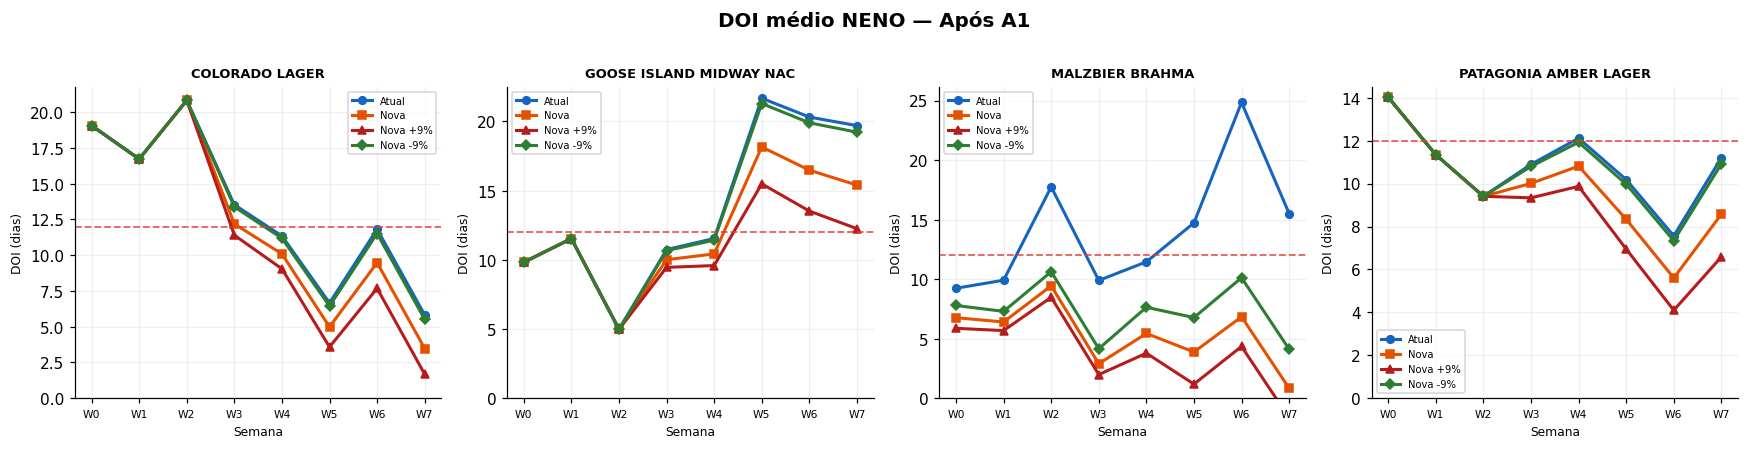

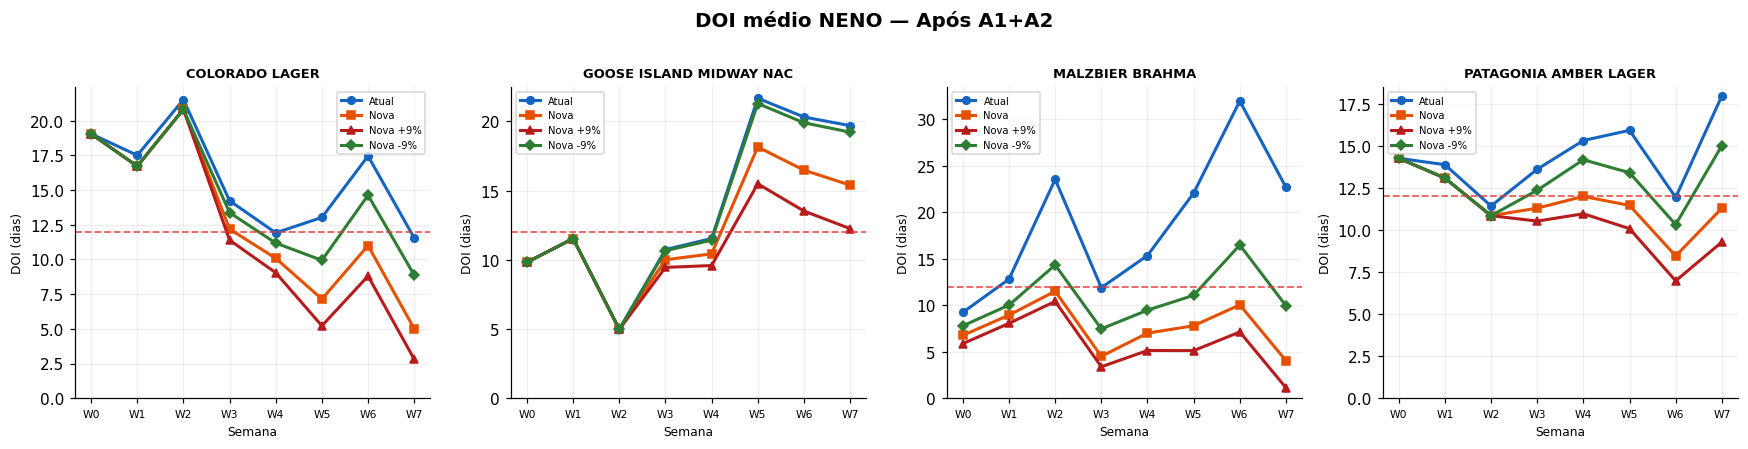

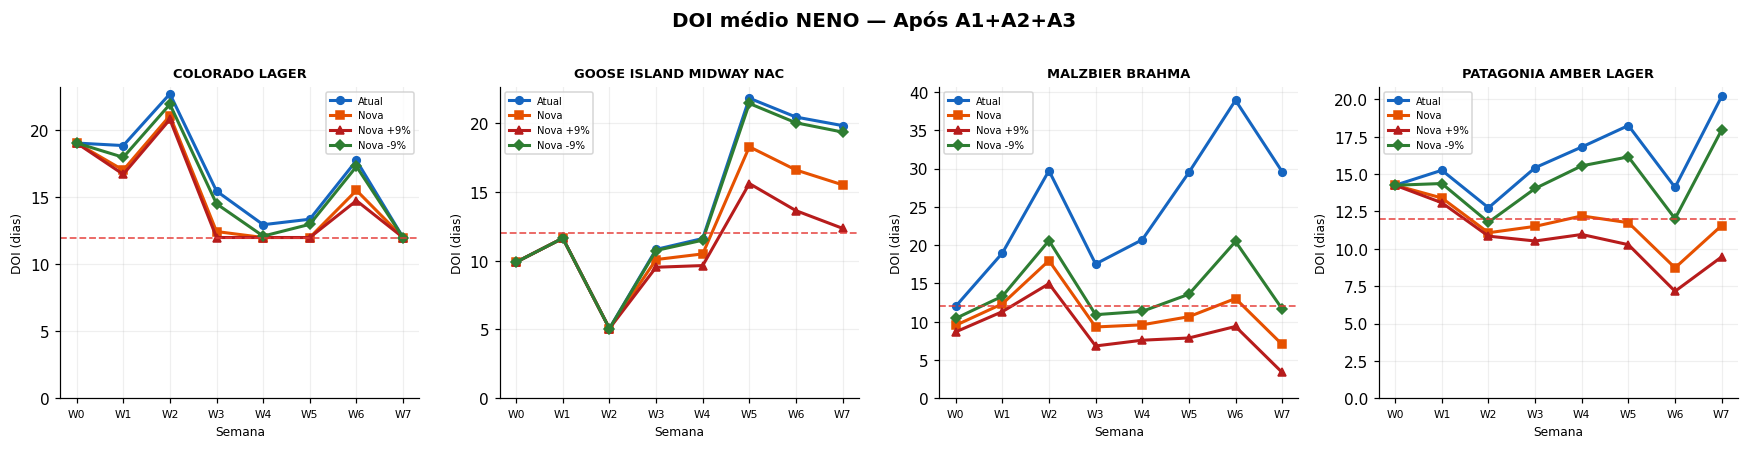

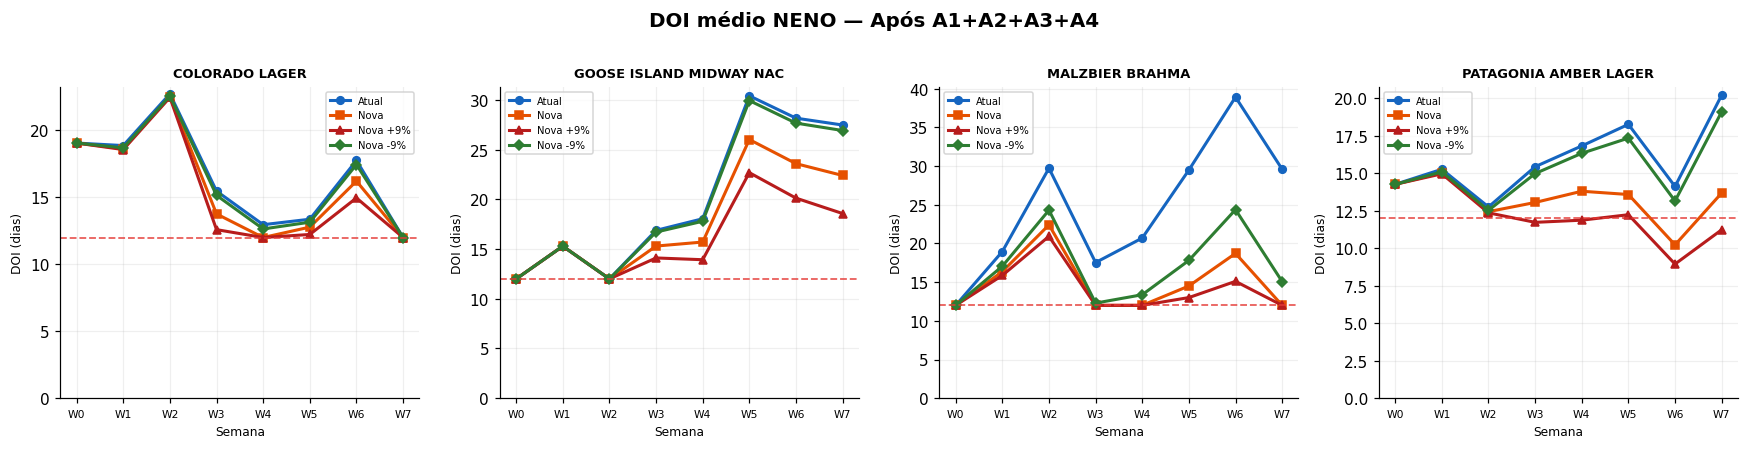

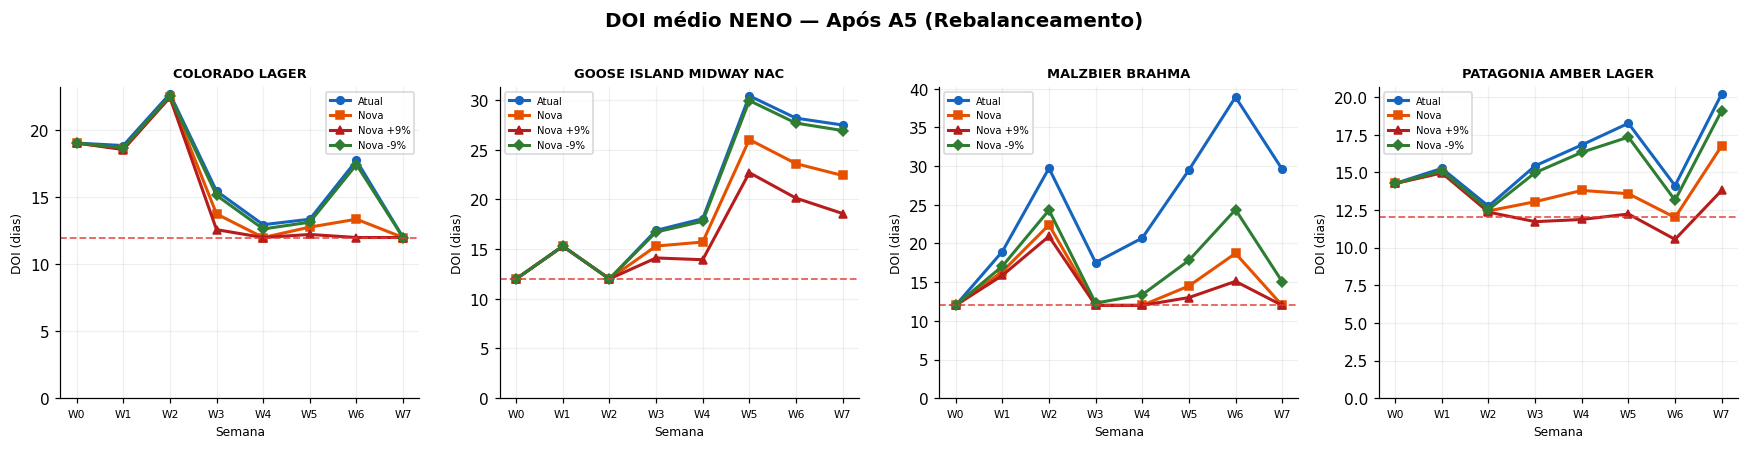


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  2. DOI MEDIO NENO POR CERVEJA — POS-RESOLUCAO (A1+A2+A3+A4)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


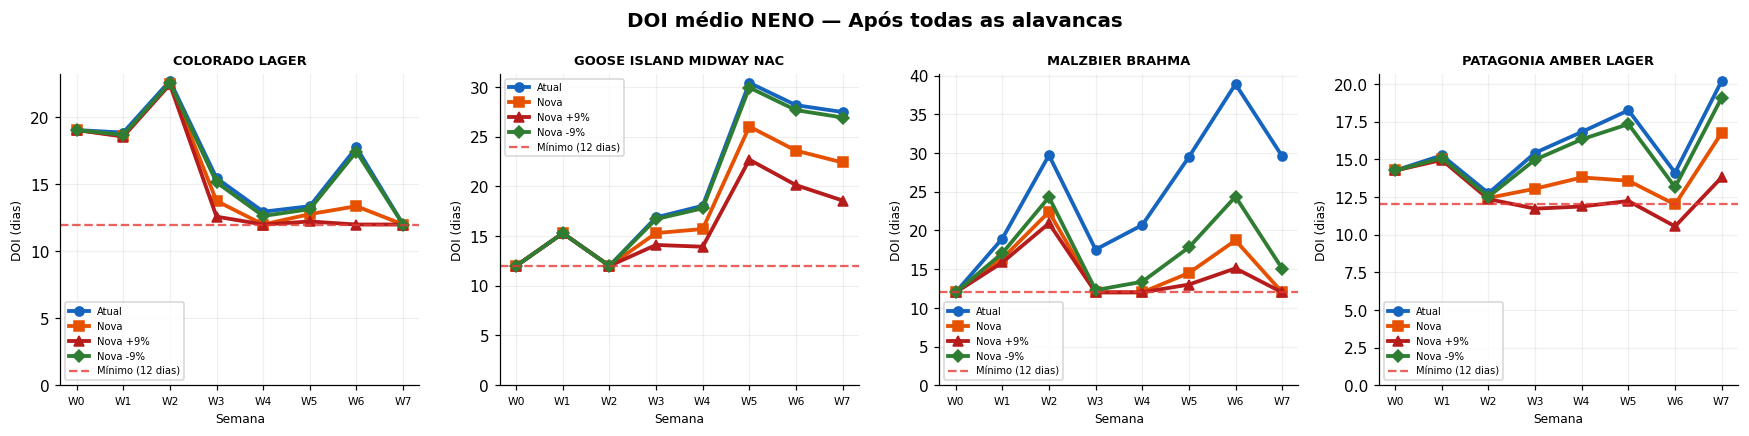


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  3. PATAGONIA — DOI POR REGIAO POS-RESOLUCAO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


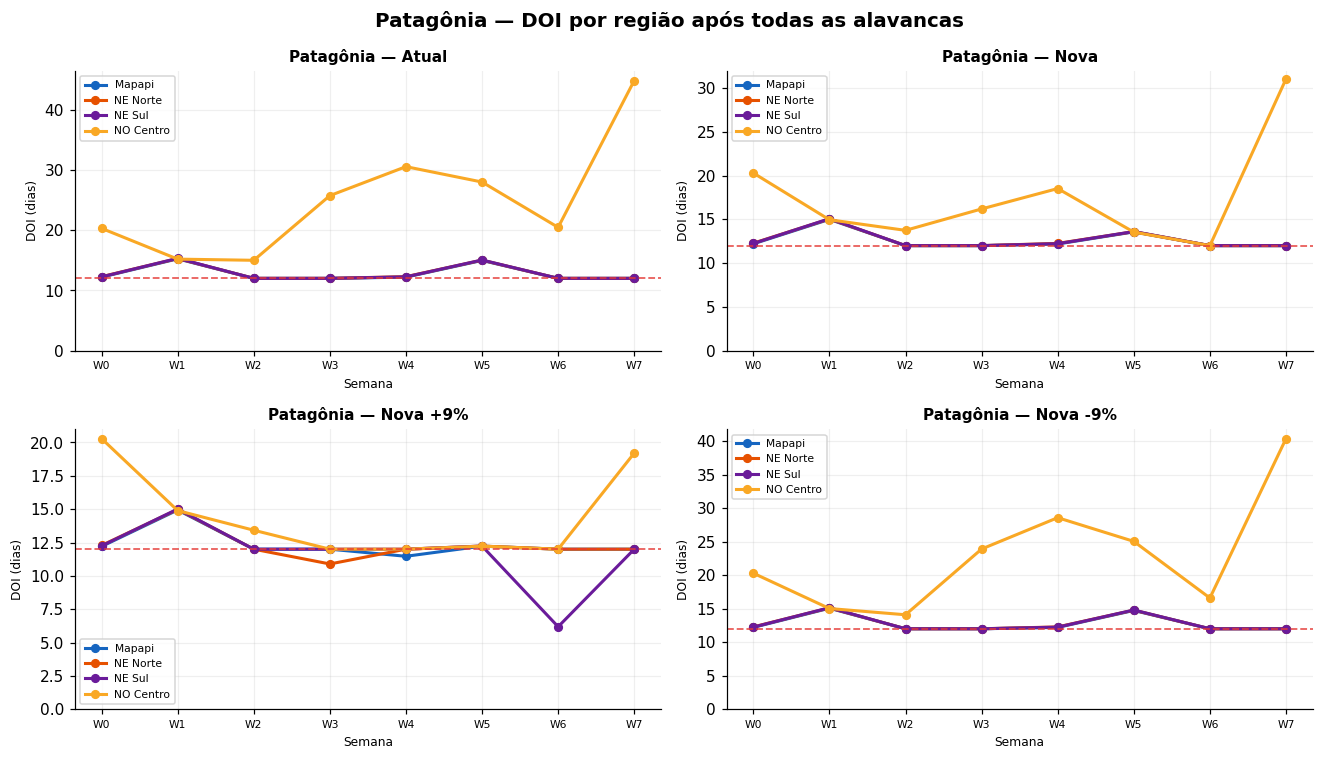


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  4. ROBUSTEZ DO CENARIO — IMPACTO DO BIAS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


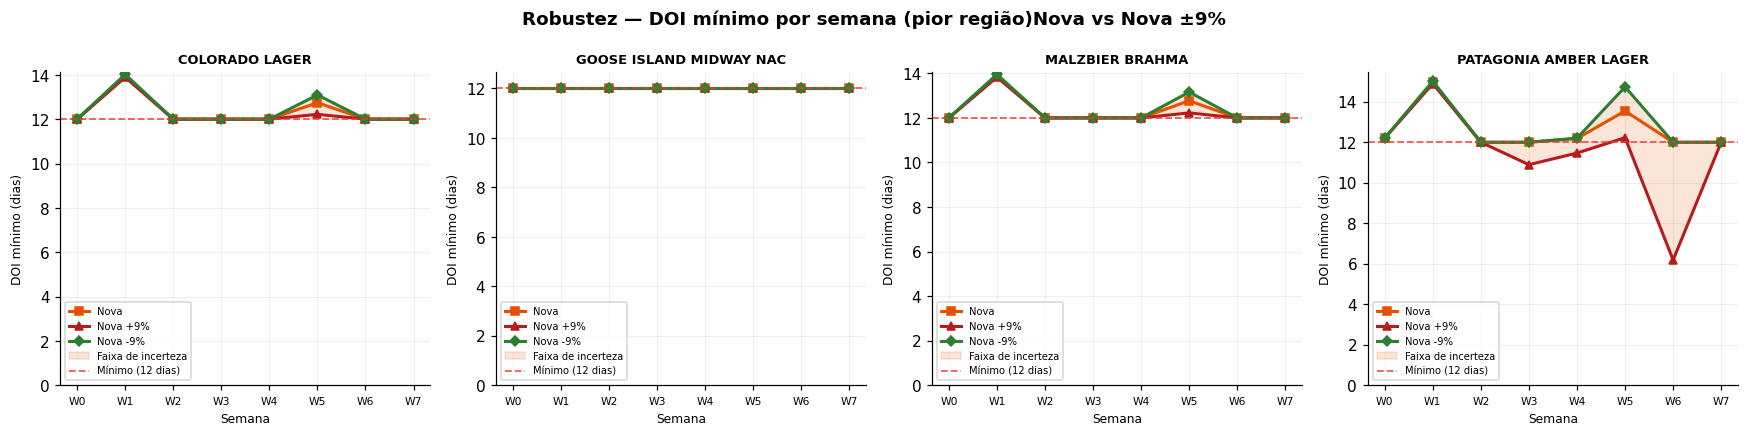


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  5. CUSTO OPERACIONAL TOTAL POR CENARIO E ETAPA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Cenario,A2 - Prod NENO,A3 - Transf SP,A4 - Prod+Transf SP,A5 - Rebal. NENO,TOTAL
0,Atual,"R$1,844,238","R$3,041,956","R$7,616,250","R$7,616,250","R$7,616,250"
1,Nova,"R$2,098,301","R$4,210,888","R$13,082,243","R$13,314,603","R$13,314,603"
2,Nova +9%,"R$2,047,096","R$4,534,579","R$17,502,263","R$17,763,650","R$17,763,650"
3,Nova -9%,"R$2,148,525","R$3,441,305","R$9,687,830","R$9,687,830","R$9,687,830"


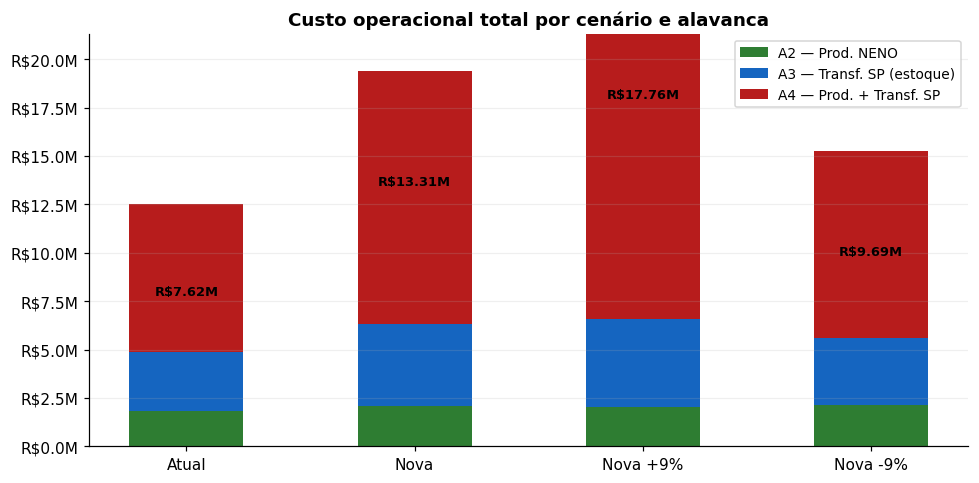


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  6. USO DE MODAL — CABOTAGEM vs RODOVIARIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Cenário,HL Cabo,HL Rodo,Total HL movido,Programações Cabo,Programações Rodo
0,Atual,217,"24,350","24,567",1,4
1,Nova,"12,012","34,174","46,186",6,5
2,Nova +9%,"29,437","37,121","66,558",8,5
3,Nova -9%,509,"31,227","31,736",1,5


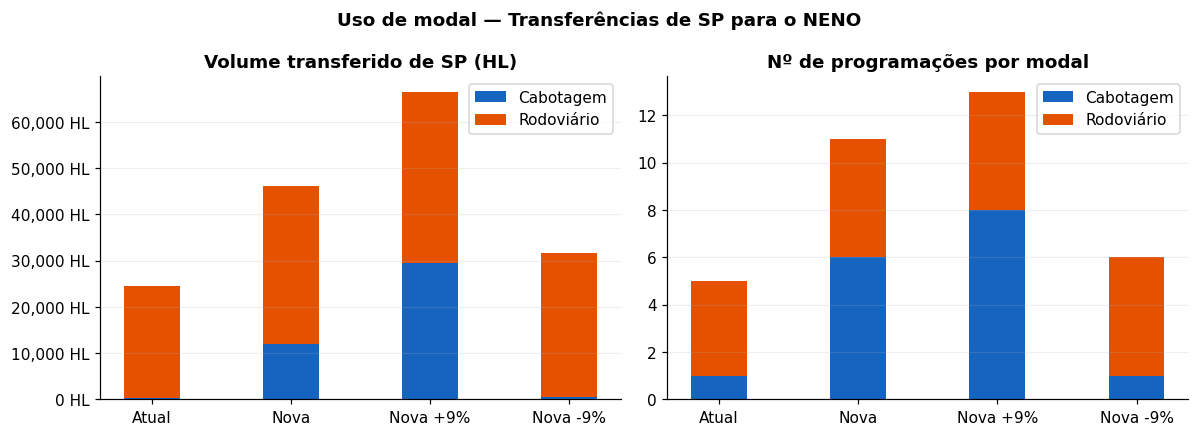


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  7. ANALISE DE MARKETSHARE — MACO vs CUSTO MARGINAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Cenário,Custo incremental,Volume incremental (HL),Custo marginal (R$/HL),MACO ponderado (R$/HL),Viável?
0,Nova,"R$5,698,353","39,166",R$145.49,R$272.01,✓ SIM
1,Nova +9%,"R$10,147,400","61,144",R$165.96,R$269.19,✓ SIM
2,Nova -9%,"R$2,071,580","17,815",R$116.28,R$282.14,✓ SIM


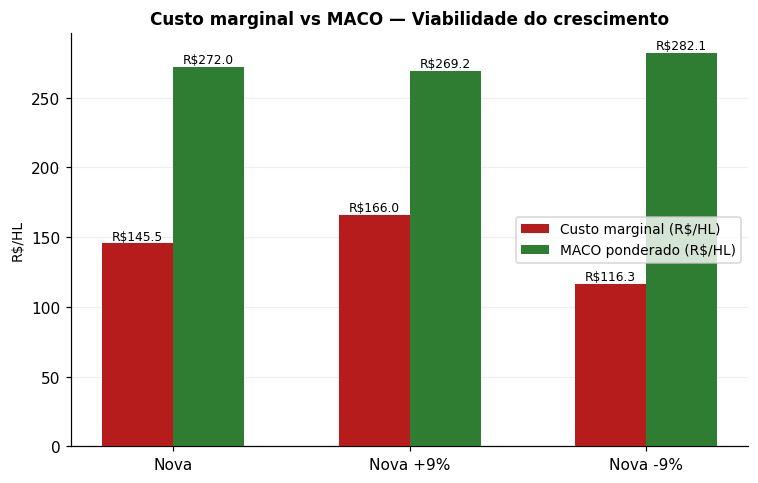


Conclusão:
  ✓ SIM Nova         | Custo marginal: R$145.49/HL | MACO: R$272.01/HL
  ✓ SIM Nova +9%     | Custo marginal: R$165.96/HL | MACO: R$269.19/HL
  ✓ SIM Nova -9%     | Custo marginal: R$116.28/HL | MACO: R$282.14/HL


In [138]:
# NOTA: Graficos e KPIs usam resultados da Alavanca 5 (A5),
# que incorpora o rebalanceamento de producao Colorado -> Patagonia no CE.
# Para comparar com A4 (sem rebalanceamento), substitua as variaveis *_a5 por *_a4.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# ── Paleta e configuracoes ───────────────────────────────────────
CENARIOS    = ["atual", "nova", "nova_bias_pos", "nova_bias_neg"]
LABELS_CEN  = {"atual": "Atual", "nova": "Nova", "nova_bias_pos": "Nova +9%", "nova_bias_neg": "Nova -9%"}
CORES_CEN   = {"atual": "#1565C0", "nova": "#E65100", "nova_bias_pos": "#B71C1C", "nova_bias_neg": "#2E7D32"}
MARKERS_CEN = {"atual": "o", "nova": "s", "nova_bias_pos": "^", "nova_bias_neg": "D"}

plt.rcParams.update({"font.family": "sans-serif", "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})

semanas_labels = neno_atual_a5.sort_values("semana_idx")["semana"].unique()
skus = sorted(neno_atual_a5["sku"].unique())

DFS = {
    "baseline": {"atual": neno_atual},
    "A1":       {"atual": neno_atual_a1, "nova": neno_nova_a1,
                 "nova_bias_pos": neno_nova_bp_a1, "nova_bias_neg": neno_nova_bn_a1},
    "A1+A2":    {"atual": neno_atual_a2, "nova": neno_nova_a2,
                 "nova_bias_pos": neno_nova_bp_a2, "nova_bias_neg": neno_nova_bn_a2},
    "A1+A2+A3": {"atual": neno_atual_a3, "nova": neno_nova_a3,
                 "nova_bias_pos": neno_nova_bp_a3, "nova_bias_neg": neno_nova_bn_a3},
    "A1+A2+A3+A4": {"atual": neno_atual_a4, "nova": neno_nova_a4,
                    "nova_bias_pos": neno_nova_bp_a4, "nova_bias_neg": neno_nova_bn_a4},
    "A5":           {"atual": neno_atual_a5, "nova": neno_nova_a5,
                    "nova_bias_pos": neno_nova_bp_a5, "nova_bias_neg": neno_nova_bn_a5},
}
ETAPAS = ["A1", "A1+A2", "A1+A2+A3", "A1+A2+A3+A4", "A5"]
ETAPA_LABELS = {"A1": "Após A1", "A1+A2": "Após A1+A2",
                "A1+A2+A3": "Após A1+A2+A3", "A1+A2+A3+A4": "Após A1+A2+A3+A4",
                "A5": "Após A5 (Rebalanceamento)"}

# ════════════════════════════════════════════════════════════════
# 1. DOI MEDIO NENO — UM GRAFICO POR ETAPA
# ════════════════════════════════════════════════════════════════
print("━" * 65)
print("  1. EVOLUCAO DO DOI MEDIO NENO POR ETAPA")
print("━" * 65)

for etapa in ETAPAS:
    fig, axes = plt.subplots(1, len(skus), figsize=(4 * len(skus), 4), sharey=False)
    if len(skus) == 1:
        axes = [axes]
    fig.suptitle(f"DOI médio NENO — {ETAPA_LABELS[etapa]}", fontsize=13, fontweight="bold", y=1.01)

    for ax, sku in zip(axes, skus):
        for cen in CENARIOS:
            df = DFS[etapa][cen] if cen in DFS[etapa] else DFS["A1+A2+A3+A4"][cen]
            doi = (df[df["sku"] == sku]
                   .groupby("semana_idx")["suf_f_d"]
                   .mean())
            ax.plot(doi.index, doi.values,
                    marker=MARKERS_CEN[cen], color=CORES_CEN[cen],
                    label=LABELS_CEN[cen], linewidth=2, markersize=5)
        ax.axhline(12, color="#E53935", linestyle="--", linewidth=1.2, alpha=0.8)
        ax.set_title(sku.split("LN")[0].strip(), fontsize=8.5, fontweight="bold")
        ax.set_xlabel("Semana", fontsize=8)
        ax.set_ylabel("DOI (dias)", fontsize=8)
        ax.set_xticks(range(8))
        ax.set_xticklabels([f"W{i}" for i in range(8)], fontsize=7)
        ax.legend(fontsize=6.5)
        ax.grid(True, alpha=0.2)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════
# 2. DOI MEDIO NENO POS-RESOLUCAO (todas as alavancas)
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  2. DOI MEDIO NENO POR CERVEJA — POS-RESOLUCAO (A1+A2+A3+A4)")
print("━" * 65)

fig, axes = plt.subplots(1, len(skus), figsize=(4 * len(skus), 4), sharey=False)
if len(skus) == 1:
    axes = [axes]
fig.suptitle("DOI médio NENO — Após todas as alavancas", fontsize=13, fontweight="bold")

for ax, sku in zip(axes, skus):
    for cen in CENARIOS:
        df = DFS["A5"][cen]
        doi = df[df["sku"] == sku].groupby("semana_idx")["suf_f_d"].mean()
        ax.plot(doi.index, doi.values,
                marker=MARKERS_CEN[cen], color=CORES_CEN[cen],
                label=LABELS_CEN[cen], linewidth=2.5, markersize=6)
    ax.axhline(12, color="#E53935", linestyle="--", linewidth=1.5, alpha=0.8, label="Mínimo (12 dias)")
    ax.set_title(sku.split("LN")[0].strip(), fontsize=8.5, fontweight="bold")
    ax.set_xlabel("Semana", fontsize=8)
    ax.set_ylabel("DOI (dias)", fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f"W{i}" for i in range(8)], fontsize=7)
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# 3. PATAGONIA POS-RESOLUCAO
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  3. PATAGONIA — DOI POR REGIAO POS-RESOLUCAO")
print("━" * 65)

regioes = sorted(neno_atual_a5["geo_reg"].unique())
CORES_REG = {"Mapapi": "#1565C0", "NE Norte": "#E65100", "NE Sul": "#6A1B9A",
             "NO Araguaia": "#2E7D32", "NO Centro": "#F9A825"}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
axes = axes.flatten()

for ax, cen in zip(axes, CENARIOS):
    df = DFS["A5"][cen]
    df_pat = df[df["sku"] == SKU_PATAGONIA]
    for geo in regioes:
        sub = df_pat[df_pat["geo_reg"] == geo].sort_values("semana_idx")
        if sub.empty:
            continue
        ax.plot(sub["semana_idx"], sub["suf_f_d"],
                marker="o", color=CORES_REG.get(geo, "gray"),
                label=geo, linewidth=2, markersize=5)
    ax.axhline(12, color="#E53935", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(f"Patagônia — {LABELS_CEN[cen]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Semana", fontsize=8)
    ax.set_ylabel("DOI (dias)", fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f"W{i}" for i in range(8)], fontsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(bottom=0)

fig.suptitle("Patagônia — DOI por região após todas as alavancas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# 4. ROBUSTEZ DO CENARIO (Bias)
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  4. ROBUSTEZ DO CENARIO — IMPACTO DO BIAS")
print("━" * 65)

fig, axes = plt.subplots(1, len(skus), figsize=(4 * len(skus), 4))
if len(skus) == 1:
    axes = [axes]
fig.suptitle("Robustez — DOI mínimo por semana (pior região)Nova vs Nova ±9%", fontsize=12, fontweight="bold")

cens_bias = ["nova", "nova_bias_pos", "nova_bias_neg"]
for ax, sku in zip(axes, skus):
    for cen in cens_bias:
        df = DFS["A5"][cen]
        doi_min = df[df["sku"] == sku].groupby("semana_idx")["suf_f_d"].min()
        ax.plot(doi_min.index, doi_min.values,
                marker=MARKERS_CEN[cen], color=CORES_CEN[cen],
                label=LABELS_CEN[cen], linewidth=2, markersize=5)

    # Faixa de incerteza entre bias_pos e bias_neg
    doi_bp = DFS["A5"]["nova_bias_pos"][
        DFS["A5"]["nova_bias_pos"]["sku"] == sku
    ].groupby("semana_idx")["suf_f_d"].min()
    doi_bn = DFS["A5"]["nova_bias_neg"][
        DFS["A5"]["nova_bias_neg"]["sku"] == sku
    ].groupby("semana_idx")["suf_f_d"].min()
    ax.fill_between(doi_bp.index, doi_bn.values, doi_bp.values,
                    alpha=0.15, color="#E65100", label="Faixa de incerteza")

    ax.axhline(12, color="#E53935", linestyle="--", linewidth=1.2, alpha=0.8, label="Mínimo (12 dias)")
    ax.set_title(sku.split("LN")[0].strip(), fontsize=8.5, fontweight="bold")
    ax.set_xlabel("Semana", fontsize=8)
    ax.set_ylabel("DOI mínimo (dias)", fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f"W{i}" for i in range(8)], fontsize=7)
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# 5. CUSTO OPERACIONAL TOTAL
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  5. CUSTO OPERACIONAL TOTAL POR CENARIO E ETAPA")
print("━" * 65)

custo_rows = []
for cen in CENARIOS:
    c2 = (custo_a2_atual if cen=="atual" else custo_a2_nova if cen=="nova"
          else custo_a2_nova_bp if cen=="nova_bias_pos" else custo_a2_nova_bn)[cen]
    c3 = (custo_a3_atual if cen=="atual" else custo_a3_nova if cen=="nova"
          else custo_a3_nova_bp if cen=="nova_bias_pos" else custo_a3_nova_bn)[cen]
    c4 = (custo_a4_atual if cen=="atual" else custo_a4_nova if cen=="nova"
          else custo_a4_nova_bp if cen=="nova_bias_pos" else custo_a4_nova_bn)[cen]
    c5 = (custo_a5_atual if cen=="atual" else custo_a5_nova if cen=="nova"
          else custo_a5_nova_bp if cen=="nova_bias_pos" else custo_a5_nova_bn)[cen]
    custo_rows.append({"cenario": cen, "A2_prod_neno": c2, "A3_transf_sp": c3, "A4_prod_sp": c4, "A5_rebal": c5, "total": c5})

df_custo = pd.DataFrame(custo_rows)

# Tabela formatada
df_fmt = df_custo.copy()
df_fmt["Cenario"] = df_fmt["cenario"].map(LABELS_CEN)
for col, lbl in [("A2_prod_neno","A2 - Prod NENO"), ("A3_transf_sp","A3 - Transf SP"),
                 ("A4_prod_sp","A4 - Prod+Transf SP"), ("A5_rebal","A5 - Rebal. NENO"), ("total","TOTAL")]:
    df_fmt[lbl] = df_fmt[col].apply(lambda v: f"R${v:,.0f}")
display(df_fmt[["Cenario","A2 - Prod NENO","A3 - Transf SP","A4 - Prod+Transf SP","A5 - Rebal. NENO","TOTAL"]])

# Grafico barras empilhadas
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CENARIOS))
w = 0.5
b1 = ax.bar(x, df_custo["A2_prod_neno"], width=w, color="#2E7D32", label="A2 — Prod. NENO")
b2 = ax.bar(x, df_custo["A3_transf_sp"], width=w, bottom=df_custo["A2_prod_neno"],
            color="#1565C0", label="A3 — Transf. SP (estoque)")
b3 = ax.bar(x, df_custo["A4_prod_sp"], width=w,
            bottom=df_custo["A2_prod_neno"] + df_custo["A3_transf_sp"],
            color="#B71C1C", label="A4 — Prod. + Transf. SP")

for i, row in df_custo.iterrows():
    ax.text(i, row["total"] + 50000, f"R${row['total']/1e6:.2f}M",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([LABELS_CEN[c] for c in CENARIOS], fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v/1e6:.1f}M"))
ax.set_title("Custo operacional total por cenário e alavanca", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")
ax.set_ylim(0, df_custo["total"].max() * 1.2)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# 6. USO DE MODAL (CABO vs RODO)
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  6. USO DE MODAL — CABOTAGEM vs RODOVIARIO")
print("━" * 65)

DFS_A2_all = {"atual": neno_atual_a2, "nova": neno_nova_a2,
              "nova_bias_pos": neno_nova_bp_a2, "nova_bias_neg": neno_nova_bn_a2}

modal_rows = []
for cen in CENARIOS:
    df_a2 = DFS_A2_all[cen]
    df_a4 = DFS["A1+A2+A3+A4"][cen]
    merge = df_a2[["sku","cenario","geo_reg","semana_idx","transito","transf_ext_rodo"]].merge(
        df_a4[["sku","cenario","geo_reg","semana_idx","transito","transf_ext_rodo"]],
        on=["sku","cenario","geo_reg","semana_idx"], suffixes=("_a2","_a4")
    )
    hl_cabo = (merge["transito_a4"]        - merge["transito_a2"]).clip(lower=0).sum()
    hl_rodo = (merge["transf_ext_rodo_a4"] - merge["transf_ext_rodo_a2"]).clip(lower=0).sum()
    n_cabo  = ((merge["transito_a4"]        - merge["transito_a2"])       > 1e-3).sum()
    n_rodo  = ((merge["transf_ext_rodo_a4"] - merge["transf_ext_rodo_a2"]) > 1e-3).sum()
    modal_rows.append({"Cenário": LABELS_CEN[cen],
                       "HL Cabo": round(hl_cabo), "HL Rodo": round(hl_rodo),
                       "Total HL movido": round(hl_cabo + hl_rodo),
                       "Programações Cabo": n_cabo, "Programações Rodo": n_rodo})

df_modal = pd.DataFrame(modal_rows)
for col in ["HL Cabo","HL Rodo","Total HL movido"]:
    df_modal[col] = df_modal[col].apply(lambda v: f"{v:,.0f}")
display(df_modal)

# Grafico
df_modal_plot = pd.DataFrame(modal_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(CENARIOS))
w = 0.4

axes[0].bar(x, df_modal_plot["HL Cabo"], width=w, color="#1565C0", label="Cabotagem")
axes[0].bar(x, df_modal_plot["HL Rodo"], width=w, bottom=df_modal_plot["HL Cabo"],
            color="#E65100", label="Rodoviário")
axes[0].set_xticks(x); axes[0].set_xticklabels([LABELS_CEN[c] for c in CENARIOS])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} HL"))
axes[0].set_title("Volume transferido de SP (HL)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.2, axis="y")

axes[1].bar(x, df_modal_plot["Programações Cabo"], width=w, color="#1565C0", label="Cabotagem")
axes[1].bar(x, df_modal_plot["Programações Rodo"], width=w,
            bottom=df_modal_plot["Programações Cabo"], color="#E65100", label="Rodoviário")
axes[1].set_xticks(x); axes[1].set_xticklabels([LABELS_CEN[c] for c in CENARIOS])
axes[1].set_title("Nº de programações por modal", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis="y")

fig.suptitle("Uso de modal — Transferências de SP para o NENO", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# 7. ANALISE DE MARKETSHARE
# ════════════════════════════════════════════════════════════════
print("\n" + "━" * 65)
print("  7. ANALISE DE MARKETSHARE — MACO vs CUSTO MARGINAL")
print("━" * 65)

maco_hl  = maco.set_index("sku")["maco_hl"].to_dict()
cen_base = "atual"
custo_base = df_custo[df_custo["cenario"] == cen_base]["total"].values[0]
vol_base   = DFS["A5"][cen_base]["demanda"].sum()

mshare_rows = []
for cen in ["nova", "nova_bias_pos", "nova_bias_neg"]:
    custo_cresc = df_custo[df_custo["cenario"] == cen]["total"].values[0]
    vol_cresc   = DFS["A5"][cen]["demanda"].sum()
    custo_inc   = custo_cresc - custo_base
    vol_inc     = vol_cresc   - vol_base
    custo_marg  = custo_inc / vol_inc if vol_inc > 0 else float("inf")

    maco_pond = 0.0
    for sku in skus:
        vi = (DFS["A5"][cen][DFS["A5"][cen]["sku"]==sku]["demanda"].sum()
            - DFS["A5"][cen_base][DFS["A5"][cen_base]["sku"]==sku]["demanda"].sum())
        if vi > 0:
            maco_pond += vi * maco_hl.get(sku, 0)
    maco_pond = maco_pond / vol_inc if vol_inc > 0 else 0

    viavel = maco_pond > custo_marg
    mshare_rows.append({
        "Cenário":                 LABELS_CEN[cen],
        "Custo incremental":       custo_inc,
        "Volume incremental (HL)": round(vol_inc),
        "Custo marginal (R$/HL)":  custo_marg,
        "MACO ponderado (R$/HL)":  maco_pond,
        "Viável?":                 "✓ SIM" if viavel else "✗ NÃO",
    })

df_ms = pd.DataFrame(mshare_rows)
df_ms_fmt = df_ms.copy()
df_ms_fmt["Custo incremental"]      = df_ms_fmt["Custo incremental"].apply(lambda v: f"R${v:,.0f}")
df_ms_fmt["Volume incremental (HL)"]= df_ms_fmt["Volume incremental (HL)"].apply(lambda v: f"{v:,.0f}")
df_ms_fmt["Custo marginal (R$/HL)"] = df_ms_fmt["Custo marginal (R$/HL)"].apply(lambda v: f"R${v:,.2f}")
df_ms_fmt["MACO ponderado (R$/HL)"] = df_ms_fmt["MACO ponderado (R$/HL)"].apply(lambda v: f"R${v:,.2f}")
display(df_ms_fmt)

# Grafico MACO vs Custo marginal
fig, ax = plt.subplots(figsize=(7, 4.5))
cens_comp = ["nova", "nova_bias_pos", "nova_bias_neg"]
cm_vals   = [r["Custo marginal (R$/HL)"]  for r in mshare_rows]
maco_vals = [r["MACO ponderado (R$/HL)"]  for r in mshare_rows]
x = np.arange(len(cens_comp))
w = 0.3
bars_cm   = ax.bar(x - w/2, cm_vals,   width=w, color="#B71C1C", label="Custo marginal (R$/HL)", zorder=3)
bars_maco = ax.bar(x + w/2, maco_vals, width=w, color="#2E7D32", label="MACO ponderado (R$/HL)", zorder=3)

for bar in bars_cm:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"R${bar.get_height():,.1f}", ha="center", va="bottom", fontsize=8)
for bar in bars_maco:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"R${bar.get_height():,.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([LABELS_CEN[c] for c in cens_comp], fontsize=10)
ax.set_ylabel("R$/HL", fontsize=9)
ax.set_title("Custo marginal vs MACO — Viabilidade do crescimento", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

print("\nConclusão:")
for r in mshare_rows:
    print(f"  {r['Viável?']} {r['Cenário']:12s} | Custo marginal: R${r['Custo marginal (R$/HL)']:,.2f}/HL | MACO: R${r['MACO ponderado (R$/HL)']:,.2f}/HL")


In [140]:
import pandas as pd

CENARIO_VERIF = "nova"
BASE_VERIF    = neno_nova_a5

COLUNAS = ["ei_semana", "wsnp", "transf_interna",
           "transf_ext_cabo", "transf_ext_rodo", "transito",
           "demanda", "ef_semana", "suf_f_d"]

LABELS = {
    "ei_semana":       "EI Semana",
    "wsnp":            "WSNP (Producao)",
    "transf_interna":  "Transf. Interna",
    "transf_ext_cabo": "Transf. Ext (Cabo)",
    "transf_ext_rodo": "Transf. Ext (Rodo)",
    "transito":        "Transito",
    "demanda":         "Demanda",
    "ef_semana":       "EF Semana",
    "suf_f_d":         "Suf. f (d)",
}

df_v    = BASE_VERIF[BASE_VERIF["cenario"] == CENARIO_VERIF].copy()
semanas = sorted(df_v["semana_idx"].unique())
sem_map = df_v.drop_duplicates("semana_idx").set_index("semana_idx")["semana"].to_dict()

for sku in sorted(df_v["sku"].unique()):
    df_sku  = df_v[df_v["sku"] == sku]
    regioes = sorted(df_sku["geo_reg"].unique())

    for w in semanas:
        df_w = df_sku[df_sku["semana_idx"] == w].set_index("geo_reg")

        print(f"\n{'='*85}")
        print(f"  {sku.split('LN')[0].strip()}  |  {sem_map.get(w, f'W{w}')}  |  Cenario: {CENARIO_VERIF}")
        print(f"{'='*85}")

        rows = []
        for geo in regioes:
            if geo not in df_w.index:
                continue
            row = {"GEO/REG": geo}
            for col, label in LABELS.items():
                val = float(df_w.loc[geo, col]) if col in df_w.columns else 0.0
                row[label] = f"{val:.1f}" if col == "suf_f_d" else f"{val:,.0f}"
            rows.append(row)

        total = {"GEO/REG": "TOTAL"}
        for col, label in LABELS.items():
            if col == "suf_f_d":
                total[label] = ""
            else:
                total[label] = f"{sum(float(df_w.loc[g, col]) for g in regioes if g in df_w.index and col in df_w.columns):,.0f}"
        rows.append(total)

        display(pd.DataFrame(rows).set_index("GEO/REG"))



  COLORADO LAGER  |  W0 - 02/02  |  Cenario: nova


,EI Semana,WSNP (Producao),Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Transito,Demanda,EF Semana,Suf. f (d)
GEO/REG,,,,,,,,,
Mapapi,"3,877",0,"1,878",0,0,0,"1,854","3,901",12.0
NE Norte,"8,016","5,400","-2,169",0,0,0,"1,371","9,877",36.6
NE Sul,"5,080",0,-274,0,0,0,"1,200","3,607",15.6
NO Centro,"4,417",0,564,0,0,0,"1,579","3,402",12.0
TOTAL,"21,390","5,400",0,0,0,0,"6,004","20,786",



  COLORADO LAGER  |  W1 - 09/02  |  Cenario: nova


,EI Semana,WSNP (Producao),Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Transito,Demanda,EF Semana,Suf. f (d)
GEO/REG,,,,,,,,,
Mapapi,"3,901",463,899,0,0,0,"1,951","3,313",14.0
NE Norte,"9,877",385,"-1,831",0,0,0,"1,620","6,811",32.2
NE Sul,"3,607",329,-38,0,0,0,"1,384","2,513",14.3
NO Centro,"3,402",404,970,-228,0,0,"1,701","2,847",14.0
TOTAL,"20,786","1,581",-0,-228,0,0,"6,655","15,484",



  COLORADO LAGER  |  W2 - 16/02  |  Cenario: nova


...

,EI Semana,WSNP (Producao),Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Transito,Demanda,EF Semana,Suf. f (d)
GEO/REG,,,,,,,,,
Mapapi,"6,511","1,447",626,0,0,0,"3,206","5,378",13.6
NE Norte,"5,604",532,"1,150",0,0,0,"2,744","4,541",13.6
NE Sul,"4,843",461,975,0,0,0,"2,377","3,902",13.6
NO Centro,"5,239","2,129","-2,750",0,0,-35,"1,698","2,886",13.5
TOTAL,"22,197","4,569",0,0,0,-35,"10,024","16,707",



  PATAGONIA AMBER LAGER  |  W6 - 16/03  |  Cenario: nova


,EI Semana,WSNP (Producao),Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Transito,Demanda,EF Semana,Suf. f (d)
GEO/REG,,,,,,,,,
Mapapi,"5,378","2,130",0,0,0,0,"2,378","5,130",12.0
NE Norte,"4,541",785,"1,094",0,0,0,"2,005","4,415",12.0
NE Sul,"3,902",0,"1,625",0,0,0,"1,720","3,807",12.0
NO Centro,"2,886","5,040","-2,719",0,0,"-1,088","1,278","2,840",12.0
TOTAL,"16,707","7,955",0,0,0,"-1,088","7,382","16,192",



  PATAGONIA AMBER LAGER  |  W7 - 23/03  |  Cenario: nova


,EI Semana,WSNP (Producao),Transf. Interna,Transf. Ext (Cabo),Transf. Ext (Rodo),Transito,Demanda,EF Semana,Suf. f (d)
GEO/REG,,,,,,,,,
Mapapi,"5,130",0,"2,565",0,0,0,"2,565","5,130",12.0
NE Norte,"4,415",0,"2,208",0,0,0,"2,208","4,415",12.0
NE Sul,"3,807",0,"1,903",0,0,0,"1,903","3,807",12.0
NO Centro,"2,840","12,600","-6,676",0,0,0,"1,420","7,344",31.0
TOTAL,"16,192","12,600",0,0,0,0,"8,096","20,696",
